In [1]:
# Install required packages (run this once)
!pip install shap plotly kaleido imbalanced-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.0 MB/s eta 0:00:00


In [2]:
# Quick verification
import shap
import plotly
import imblearn
print("✅ All critical packages loaded successfully!")

✅ All critical packages loaded successfully!


In [4]:
# ============================================================================
# BLOCK 1: ENVIRONMENT SETUP AND LIBRARY IMPORTS
# ============================================================================
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
from collections import Counter
import os
import gc

# Machine Learning
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight

# Imbalanced learning
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.combine import SMOTETomek

# Interpretability
import shap

# Visualization
import plotly.graph_objects as go
import plotly.express as px

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("✅ All libraries imported successfully!")
print(f"📅 Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"🔢 NumPy version: {np.__version__}")
print(f"🐼 Pandas version: {pd.__version__}")
print(f"🤖 XGBoost version: {xgb.__version__}")

✅ All libraries imported successfully!
📅 Analysis Date: 2025-12-22 18:29
🔢 NumPy version: 2.0.2
🐼 Pandas version: 2.2.2
🤖 XGBoost version: 3.1.0


In [5]:
# ============================================================================
# BLOCK 2: CONFIGURATION AND UTILITY CLASSES (FIXED)
# ============================================================================
# Purpose: Define all hyperparameters, paths, and helper functions
# This centralizes configuration for easy tuning and reproducibility
# FIXED: Compatible with XGBoost 2.x, LightGBM, CatBoost latest versions
# ============================================================================

class Config:
    """Central configuration for the entire pipeline"""
    
    # File paths
    INPUT_FILE = "/kaggle/input/oasis3-clinical-data/clinical_data.csv"  # Your processed data
    OUTPUT_DIR = "/kaggle/working/"
    
    # Column names
    ID_COL = "NACCID"
    VISIT_COL = "NACCVNUM"
    CURRENT_TARGET = "target"
    FUTURE_TARGET = "future_target"
    
    # Model settings
    N_FOLDS = 5
    N_CLASS = 4
    CLASS_NAMES = ['Normal', 'MCI', 'Mild', 'Severe']
    SEED = 42
    
    # Feature engineering flags
    CREATE_INTERACTIONS = True
    CREATE_POLYNOMIALS = True
    
    # SMOTE configuration
    USE_SMOTE = True
    SMOTE_STRATEGY = 'borderline'
    
    # Class weight multipliers (tuned for minority classes)
    WEIGHT_MULTIPLIERS = {
        0: 1.0,    # Normal
        1: 1.5,    # MCI
        2: 3.0,    # Mild (heavily boosted)
        3: 2.5     # Severe
    }
    
    # XGBoost 2.x compatible parameters
    XGB_PARAMS = {
        'n_estimators': 1000,
        'learning_rate': 0.01,
        'max_depth': 12,
        'min_child_weight': 1,
        'subsample': 0.9,
        'colsample_bytree': 0.9,
        'gamma': 0.1,
        'reg_alpha': 0.3,
        'reg_lambda': 1.0,
        'tree_method': 'hist',
        'objective': 'multi:softprob',
        'num_class': N_CLASS,
        'random_state': SEED,
        'verbosity': 0
    }
    
    # LightGBM parameters
    LGB_PARAMS = {
        'n_estimators': 1000,
        'learning_rate': 0.01,
        'num_leaves': 100,
        'max_depth': 14,
        'min_child_samples': 8,
        'subsample': 0.9,
        'colsample_bytree': 0.9,
        'reg_alpha': 0.3,
        'reg_lambda': 1.0,
        'objective': 'multiclass',
        'num_class': N_CLASS,
        'random_state': SEED,
        'verbosity': -1,
        'force_col_wise': True
    }
    
    # CatBoost parameters
    CAT_PARAMS = {
        'iterations': 1000,
        'learning_rate': 0.01,
        'depth': 10,
        'l2_leaf_reg': 3,
        'border_count': 254,
        'bagging_temperature': 0.7,
        'random_strength': 0.5,
        'loss_function': 'MultiClass',
        'random_seed': SEED,
        'verbose': 0
    }
    
    # Ensemble weights
    ENSEMBLE_WEIGHTS = {
        'xgb': 0.35,
        'lgb': 0.35,
        'cat': 0.30
    }

class Logger:
    """Beautiful console logging"""
    
    @staticmethod
    def section(title):
        print(f"\n{'='*80}\n🚀 {title.upper()}\n{'='*80}")
    
    @staticmethod
    def info(msg):
        print(f"   ℹ️  {msg}")
    
    @staticmethod
    def success(msg):
        print(f"   ✅ {msg}")
    
    @staticmethod
    def warning(msg):
        print(f"   ⚠️  {msg}")
    
    @staticmethod
    def metric(name, value):
        if isinstance(value, (int, float)):
            print(f"   📊 {name}: {value:.4f}")
        else:
            print(f"   📊 {name}: {value}")

# Create output directory
os.makedirs(Config.OUTPUT_DIR, exist_ok=True)
Logger.success("Configuration loaded successfully!")
Logger.info(f"Results will be saved to: {Config.OUTPUT_DIR}")
Logger.info(f"XGBoost version: {xgb.__version__}")
Logger.info(f"LightGBM version: {lgb.__version__}")

   ✅ Configuration loaded successfully!
   ℹ️  Results will be saved to: /kaggle/working/
   ℹ️  XGBoost version: 3.1.0
   ℹ️  LightGBM version: 4.6.0



🚀 LOADING DATA AND CREATING TABLE 1
   ✅ Loaded 150,904 records from 37,633 unique patients
   ℹ️  Features: 53
   ℹ️  Date range: Visit 1 to 19

TABLE 1: BASELINE CHARACTERISTICS OF STUDY POPULATION
         Variable   Measure           Total         Normal            MCI           Mild         Severe
      Age (years) Mean ± SD     74.3 ± 10.0    73.6 ± 10.0     75.0 ± 9.5    74.8 ± 10.4    75.8 ± 10.8
           Female     n (%)   88309 (58.5%)  52230 (65.8%)  21789 (50.0%)   7880 (47.9%)   6410 (55.7%)
Education (years) Mean ± SD      16.0 ± 6.1     16.4 ± 5.7     15.9 ± 5.7     15.5 ± 7.5     15.2 ± 7.8
   APOE4 carriers     n (%) 150904 (100.0%) 79333 (100.0%) 43594 (100.0%) 16466 (100.0%) 11511 (100.0%)
      Race: White     n (%)  124728 (82.7%)  64642 (81.5%)  36068 (82.7%)  14242 (86.5%)   9776 (84.9%)
      N (samples)     Count          150904  79333 (52.6%)  43594 (28.9%)  16466 (10.9%)   11511 (7.6%)
   ✅ Table 1 saved to CSV


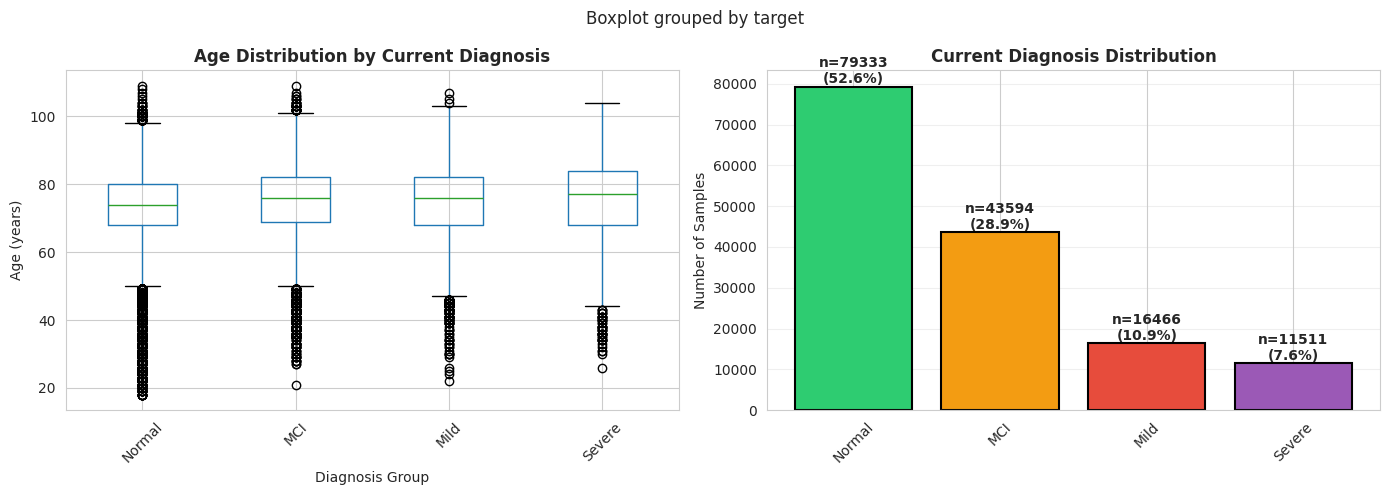

   ✅ Demographic visualizations created


In [6]:
# ============================================================================
# BLOCK 3: DATA LOADING AND DEMOGRAPHIC ANALYSIS (TABLE 1)
# ============================================================================
# Purpose: Load the processed clinical data and create Table 1
# Table 1 is mandatory for medical papers - shows dataset characteristics
# ============================================================================

Logger.section("Loading Data and Creating Table 1")

# Load data
df = pd.read_csv(Config.INPUT_FILE)
Logger.success(f"Loaded {len(df):,} records from {df[Config.ID_COL].nunique():,} unique patients")

# Basic info
Logger.info(f"Features: {len(df.columns)}")
Logger.info(f"Date range: Visit {df[Config.VISIT_COL].min()} to {df[Config.VISIT_COL].max()}")

# Create Table 1: Demographic Characteristics by Diagnosis Group
def create_table1(df, target_col=Config.CURRENT_TARGET):
    """Generate demographic summary table (required for all medical papers)"""
    
    results = []
    
    # Overall
    total_n = len(df)
    
    # By diagnosis group
    groups = sorted(df[target_col].unique())
    
    # Age
    if 'NACCAGE' in df.columns:
        row = {'Variable': 'Age (years)', 'Measure': 'Mean ± SD'}
        row['Total'] = f"{df['NACCAGE'].mean():.1f} ± {df['NACCAGE'].std():.1f}"
        for g in groups:
            subset = df[df[target_col] == g]
            row[Config.CLASS_NAMES[g]] = f"{subset['NACCAGE'].mean():.1f} ± {subset['NACCAGE'].std():.1f}"
        results.append(row)
    
    # Sex
    if 'SEX' in df.columns:
        row = {'Variable': 'Female', 'Measure': 'n (%)'}
        female_total = (df['SEX'] == 2).sum()
        row['Total'] = f"{female_total} ({female_total/total_n*100:.1f}%)"
        for g in groups:
            subset = df[df[target_col] == g]
            female_count = (subset['SEX'] == 2).sum()
            row[Config.CLASS_NAMES[g]] = f"{female_count} ({female_count/len(subset)*100:.1f}%)"
        results.append(row)
    
    # Education
    if 'EDUC' in df.columns:
        row = {'Variable': 'Education (years)', 'Measure': 'Mean ± SD'}
        row['Total'] = f"{df['EDUC'].mean():.1f} ± {df['EDUC'].std():.1f}"
        for g in groups:
            subset = df[df[target_col] == g]
            row[Config.CLASS_NAMES[g]] = f"{subset['EDUC'].mean():.1f} ± {subset['EDUC'].std():.1f}"
        results.append(row)
    
    # APOE4
    if 'NACCAPOE' in df.columns:
        row = {'Variable': 'APOE4 carriers', 'Measure': 'n (%)'}
        apoe4_total = (df['NACCAPOE'] >= 1).sum()
        row['Total'] = f"{apoe4_total} ({apoe4_total/total_n*100:.1f}%)"
        for g in groups:
            subset = df[df[target_col] == g]
            apoe4_count = (subset['NACCAPOE'] >= 1).sum()
            row[Config.CLASS_NAMES[g]] = f"{apoe4_count} ({apoe4_count/len(subset)*100:.1f}%)"
        results.append(row)
    
    # Race (if available)
    if 'RACE' in df.columns:
        # Assuming 1=White, 2=Black, etc.
        row = {'Variable': 'Race: White', 'Measure': 'n (%)'}
        white_total = (df['RACE'] == 1).sum()
        row['Total'] = f"{white_total} ({white_total/total_n*100:.1f}%)"
        for g in groups:
            subset = df[df[target_col] == g]
            white_count = (subset['RACE'] == 1).sum()
            row[Config.CLASS_NAMES[g]] = f"{white_count} ({white_count/len(subset)*100:.1f}%)"
        results.append(row)
    
    # Sample sizes
    row = {'Variable': 'N (samples)', 'Measure': 'Count'}
    row['Total'] = f"{total_n}"
    for g in groups:
        count = (df[target_col] == g).sum()
        row[Config.CLASS_NAMES[g]] = f"{count} ({count/total_n*100:.1f}%)"
    results.append(row)
    
    return pd.DataFrame(results)

# Generate Table 1
table1 = create_table1(df)
print("\n" + "="*80)
print("TABLE 1: BASELINE CHARACTERISTICS OF STUDY POPULATION")
print("="*80)
print(table1.to_string(index=False))
print("="*80)

# Save Table 1
table1.to_csv(f"{Config.OUTPUT_DIR}/table1_demographics.csv", index=False)
Logger.success("Table 1 saved to CSV")

# Visualize age distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age by diagnosis
if 'NACCAGE' in df.columns:
    df.boxplot(column='NACCAGE', by=Config.CURRENT_TARGET, ax=axes[0])
    axes[0].set_title('Age Distribution by Current Diagnosis', fontweight='bold')
    axes[0].set_xlabel('Diagnosis Group')
    axes[0].set_ylabel('Age (years)')
    axes[0].set_xticklabels(Config.CLASS_NAMES)
    plt.sca(axes[0])
    plt.xticks(rotation=45)

# Class distribution
class_counts = df[Config.CURRENT_TARGET].value_counts().sort_index()
axes[1].bar(range(Config.N_CLASS), class_counts.values, 
            color=['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6'],
            edgecolor='black', linewidth=1.5)
axes[1].set_xticks(range(Config.N_CLASS))
axes[1].set_xticklabels(Config.CLASS_NAMES, rotation=45)
axes[1].set_ylabel('Number of Samples')
axes[1].set_title('Current Diagnosis Distribution', fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

for i, v in enumerate(class_counts.values):
    axes[1].text(i, v + 50, f'n={v}\n({v/len(df)*100:.1f}%)', 
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{Config.OUTPUT_DIR}/demographics_overview.png", dpi=150, bbox_inches='tight')
plt.show()

Logger.success("Demographic visualizations created")

In [7]:
# ============================================================================
# BLOCK 4: ADVANCED FEATURE ENGINEERING
# ============================================================================
# Purpose: Create sophisticated features from raw clinical data
# Includes temporal patterns, disease interactions, and progression indicators
# ============================================================================

class FeatureEngineer:
    """Creates publication-ready features for dementia progression"""
    
    def __init__(self, df):
        self.df = df.copy()
        self.feature_counts = {}
    
    def create_all_features(self):
        Logger.section("Advanced Feature Engineering")
        initial_cols = len(self.df.columns)
        
        # Sort by patient and visit
        self.df = self.df.sort_values([Config.ID_COL, Config.VISIT_COL]).reset_index(drop=True)
        
        # Track visit number
        self.df['visit_number'] = self.df.groupby(Config.ID_COL).cumcount() + 1
        
        # === CURRENT DIAGNOSIS FEATURES ===
        self._create_diagnosis_features()
        
        # === DEMOGRAPHIC FEATURES ===
        self._create_age_features()
        
        # === GENETIC FEATURES ===
        self._create_genetic_features()
        
        # === COMORBIDITY FEATURES ===
        self._create_comorbidity_features()
        
        # === TEMPORAL CHANGE FEATURES ===
        self._create_temporal_features()
        
        # === INTERACTION FEATURES ===
        if Config.CREATE_INTERACTIONS:
            self._create_interactions()
        
        Logger.success(f"Feature engineering complete!")
        Logger.info(f"Total features: {len(self.df.columns)} (added {len(self.df.columns) - initial_cols})")
        
        return self.df
    
    def _create_diagnosis_features(self):
        """Current state and progression patterns"""
        Logger.info("Creating diagnosis-based features...")
        
        # One-hot encode current diagnosis
        for i in range(Config.N_CLASS):
            self.df[f'is_{Config.CLASS_NAMES[i].lower()}_now'] = \
                (self.df[Config.CURRENT_TARGET] == i).astype(int)
        
        # Historical diagnoses (lag features)
        for lag in [1, 2, 3]:
            self.df[f'prev_diagnosis_{lag}'] = \
                self.df.groupby(Config.ID_COL)[Config.CURRENT_TARGET].shift(lag).fillna(-1).astype(int)
        
        # First visit flag
        self.df['is_first_visit'] = (self.df['prev_diagnosis_1'] == -1).astype(int)
        
        # Progression patterns
        self.df['stayed_same'] = (
            (self.df[Config.CURRENT_TARGET] == self.df['prev_diagnosis_1']) & 
            (self.df['prev_diagnosis_1'] >= 0)
        ).astype(int)
        
        self.df['progressed_recently'] = (
            (self.df[Config.CURRENT_TARGET] > self.df['prev_diagnosis_1']) & 
            (self.df['prev_diagnosis_1'] >= 0)
        ).astype(int)
        
        # Progression velocity
        self.df['progression_speed'] = (
            self.df[Config.CURRENT_TARGET] - self.df['prev_diagnosis_1']
        ).fillna(0)
        
        # Stability metrics
        self.df['diagnosis_changes'] = self.df.groupby(Config.ID_COL)[Config.CURRENT_TARGET]\
            .transform(lambda x: (x.diff() != 0).cumsum()).fillna(0)
        
        self.df['stability_score'] = 1 - (
            self.df['diagnosis_changes'] / self.df['visit_number'].clip(lower=1)
        )
        
        # Trajectory
        self.df['diagnosis_mean'] = self.df.groupby(Config.ID_COL)[Config.CURRENT_TARGET].transform('mean')
        self.df['diagnosis_std'] = self.df.groupby(Config.ID_COL)[Config.CURRENT_TARGET].transform('std').fillna(0)
        self.df['worst_diagnosis_ever'] = self.df.groupby(Config.ID_COL)[Config.CURRENT_TARGET].transform('max')
        
        self.feature_counts['diagnosis'] = len([c for c in self.df.columns if 'diagnosis' in c.lower()])
    
    def _create_age_features(self):
        """Age-related features and risk buckets"""
        if 'NACCAGE' not in self.df.columns:
            return
        
        Logger.info("Creating age features...")
        
        self.df['age_baseline'] = self.df.groupby(Config.ID_COL)['NACCAGE'].transform('first')
        self.df['years_in_study'] = self.df['NACCAGE'] - self.df['age_baseline']
        self.df['age_squared'] = self.df['NACCAGE'] ** 2
        
        # Age risk buckets (clinical thresholds)
        self.df['age_risk_extreme'] = (self.df['NACCAGE'] >= 85).astype(int)
        self.df['age_risk_very_high'] = ((self.df['NACCAGE'] >= 75) & (self.df['NACCAGE'] < 85)).astype(int)
        self.df['age_risk_high'] = ((self.df['NACCAGE'] >= 65) & (self.df['NACCAGE'] < 75)).astype(int)
        
        # Age-diagnosis interaction
        self.df['age_diagnosis_product'] = self.df['NACCAGE'] * self.df[Config.CURRENT_TARGET]
        
        self.feature_counts['age'] = 7
    
    def _create_genetic_features(self):
        """APOE4 and genetic risk features"""
        if 'NACCAPOE' not in self.df.columns:
            return
        
        Logger.info("Creating genetic features...")
        
        self.df['apoe4_any'] = (self.df['NACCAPOE'] >= 1).astype(int)
        self.df['apoe4_double'] = (self.df['NACCAPOE'] == 2).astype(int)
        self.df['apoe4_count'] = self.df['NACCAPOE'].fillna(0)
        
        # Age-APOE4 interactions (critical for AD risk)
        if 'NACCAGE' in self.df.columns:
            self.df['apoe4_age_risk'] = self.df['apoe4_any'] * self.df['NACCAGE']
            self.df['apoe4_elderly'] = (
                self.df['apoe4_any'] & (self.df['NACCAGE'] >= 70)
            ).astype(int)
        
        self.feature_counts['genetic'] = 5
    
    def _create_comorbidity_features(self):
        """Cardiovascular, neurological, and metabolic conditions"""
        Logger.info("Creating comorbidity features...")
        
        # Cardiovascular
        cv_features = ['CVHATT', 'CVAFIB', 'CVCHF', 'HYPERTEN', 'CBSTROKE', 'CBTIA']
        available_cv = [f for f in cv_features if f in self.df.columns]
        
        if available_cv:
            self.df['cv_count'] = self.df[available_cv].fillna(0).sum(axis=1)
            self.df['cv_any'] = (self.df['cv_count'] > 0).astype(int)
            self.df['cv_severe'] = (self.df['cv_count'] >= 3).astype(int)
        
        # Neurological
        neuro_features = ['SEIZURES', 'TBI', 'PARKIN', 'PD']
        available_neuro = [f for f in neuro_features if f in self.df.columns]
        
        if available_neuro:
            self.df['neuro_count'] = self.df[available_neuro].fillna(0).sum(axis=1)
            self.df['neuro_any'] = (self.df['neuro_count'] > 0).astype(int)
        
        # Metabolic
        metabolic_features = ['DIABETES', 'HYPERCHO', 'THYROID', 'B12DEF']
        available_metabolic = [f for f in metabolic_features if f in self.df.columns]
        
        if available_metabolic:
            self.df['metabolic_count'] = self.df[available_metabolic].fillna(0).sum(axis=1)
            self.df['metabolic_any'] = (self.df['metabolic_count'] > 0).astype(int)
        
        # Total comorbidity burden
        risk_components = []
        for col in ['cv_count', 'neuro_count', 'metabolic_count']:
            if col in self.df.columns:
                risk_components.append(self.df[col])
        
        if risk_components:
            self.df['total_comorbidity_score'] = sum(risk_components)
            self.df['high_comorbidity'] = (self.df['total_comorbidity_score'] >= 3).astype(int)
        
        self.feature_counts['comorbidity'] = len([c for c in self.df.columns if 'count' in c or 'comorbidity' in c])
    
    def _create_temporal_features(self):
        """Track changes over time"""
        Logger.info("Creating temporal change features...")
        
        # Important features to track changes
        change_features = ['NACCBMI', 'BPSYS', 'BPDIAS', 'HRATE', 'WEIGHT']
        change_features = [f for f in change_features if f in self.df.columns]
        
        for col in change_features:
            # Change from previous visit
            self.df[f'{col}_change'] = self.df.groupby(Config.ID_COL)[col].diff().fillna(0)
            
            # Rolling mean (smoothed)
            self.df[f'{col}_rolling_mean'] = self.df.groupby(Config.ID_COL)[col].transform(
                lambda x: x.rolling(2, min_periods=1).mean()
            )
        
        self.feature_counts['temporal'] = len(change_features) * 2
    
    def _create_interactions(self):
        """Critical feature interactions"""
        Logger.info("Creating interaction features...")
        
        # Age × APOE4 (strongest AD risk factor)
        if all(c in self.df.columns for c in ['NACCAGE', 'apoe4_any']):
            self.df['age_apoe4_interaction'] = self.df['NACCAGE'] * self.df['apoe4_any']
        
        # Age × Comorbidity
        if all(c in self.df.columns for c in ['NACCAGE', 'cv_count']):
            self.df['age_cv_interaction'] = self.df['NACCAGE'] * self.df['cv_count']
        
        # Education × Current diagnosis (cognitive reserve)
        if all(c in self.df.columns for c in ['EDUC', Config.CURRENT_TARGET]):
            self.df['educ_diagnosis_interaction'] = self.df['EDUC'] * self.df[Config.CURRENT_TARGET]
        
        self.feature_counts['interactions'] = 3

# Apply feature engineering
engineer = FeatureEngineer(df)
df_engineered = engineer.create_all_features()

Logger.success(f"Feature engineering complete! Created {len(df_engineered.columns)} features")
Logger.info("Feature breakdown:")
for category, count in engineer.feature_counts.items():
    Logger.info(f"  • {category.capitalize()}: {count} features")

# Save engineered features
df_engineered.to_csv(f"{Config.OUTPUT_DIR}/features_engineered.csv", index=False)


🚀 ADVANCED FEATURE ENGINEERING
   ℹ️  Creating diagnosis-based features...
   ℹ️  Creating age features...
   ℹ️  Creating genetic features...
   ℹ️  Creating comorbidity features...
   ℹ️  Creating temporal change features...
   ℹ️  Creating interaction features...
   ✅ Feature engineering complete!
   ℹ️  Total features: 104 (added 51)
   ✅ Feature engineering complete! Created 104 features
   ℹ️  Feature breakdown:
   ℹ️    • Diagnosis: 7 features
   ℹ️    • Age: 7 features
   ℹ️    • Genetic: 5 features
   ℹ️    • Comorbidity: 6 features
   ℹ️    • Temporal: 10 features
   ℹ️    • Interactions: 3 features


In [8]:
# ============================================================================
# BLOCK 5: PREPARE TRAINING DATA
# ============================================================================
# Purpose: Split features/targets and prepare for cross-validation
# Uses GroupKFold to prevent patient leakage across folds
# ============================================================================

def prepare_data(df):
    """Prepare X, y, groups for training"""
    Logger.section("Preparing Training Data")
    
    # Extract targets and groups
    y = df[Config.FUTURE_TARGET].copy()
    groups = df[Config.ID_COL].copy()
    
    # Drop ID columns and targets
    drop_cols = [Config.ID_COL, Config.VISIT_COL, Config.FUTURE_TARGET]
    X = df.drop(columns=drop_cols, errors='ignore')
    
    # Keep current_target as feature (valid - predicting future)
    if Config.CURRENT_TARGET not in X.columns:
        Logger.warning(f"⚠️  {Config.CURRENT_TARGET} not in features!")
    
    Logger.info(f"Features: {X.shape[1]}")
    Logger.info(f"Samples: {len(X):,}")
    Logger.info(f"Unique patients: {groups.nunique():,}")
    
    # Target distribution
    Logger.info("\n📊 Target Distribution (What we're predicting):")
    for i in range(Config.N_CLASS):
        count = (y == i).sum()
        pct = count / len(y) * 100
        Logger.info(f"   {Config.CLASS_NAMES[i]}: {count:,} ({pct:.1f}%)")
    
    # Check for class imbalance
    class_counts = Counter(y)
    max_count = max(class_counts.values())
    min_count = min(class_counts.values())
    imbalance_ratio = max_count / min_count
    
    if imbalance_ratio > 3:
        Logger.warning(f"⚠️  Class imbalance detected! Ratio: {imbalance_ratio:.1f}:1")
        Logger.info("   Will use SMOTE to balance training data")
    
    return X, y, groups

# Prepare data
X, y, groups = prepare_data(df_engineered)

# Verify no data leakage
Logger.info("\n🔒 Data Leakage Check:")
Logger.info(f"   Total samples: {len(X)}")
Logger.info(f"   Unique patients: {groups.nunique()}")
Logger.info(f"   Avg visits per patient: {len(X) / groups.nunique():.1f}")

# Store original dataframe for later analysis
df_original = df_engineered.copy()

Logger.success("Data preparation complete and verified!")


🚀 PREPARING TRAINING DATA
   ℹ️  Features: 101
   ℹ️  Samples: 150,904
   ℹ️  Unique patients: 37,633
   ℹ️  
📊 Target Distribution (What we're predicting):
   ℹ️     Normal: 76,613 (50.8%)
   ℹ️     MCI: 39,931 (26.5%)
   ℹ️     Mild: 16,342 (10.8%)
   ℹ️     Severe: 18,018 (11.9%)
   ⚠️  ⚠️  Class imbalance detected! Ratio: 4.7:1
   ℹ️     Will use SMOTE to balance training data
   ℹ️  
🔒 Data Leakage Check:
   ℹ️     Total samples: 150904
   ℹ️     Unique patients: 37633
   ℹ️     Avg visits per patient: 4.0
   ✅ Data preparation complete and verified!


Without cross validation

In [9]:
# ============================================================================
# BLOCK 6: FAST MODEL TRAINING (SINGLE TRAIN-TEST SPLIT)
# ============================================================================
# Purpose: Train ensemble model quickly using single split
# Maintains patient-level separation but ~5x faster than cross-validation
# Perfect for development, testing, and iteration
# ============================================================================

from sklearn.model_selection import GroupShuffleSplit

class OptimizedEnsemble:
    """Weighted ensemble of XGBoost, LightGBM, and CatBoost"""
    
    def __init__(self, class_weights, use_xgb=True, use_lgb=True, use_cat=True):
        self.class_weights = class_weights
        self.models = {}
        self.use_xgb = use_xgb
        self.use_lgb = use_lgb
        self.use_cat = use_cat
    
    def train(self, X_train, y_train, X_val, y_val):
        """Train all enabled models with early stopping"""
        
        if self.use_xgb:
            Logger.info("Training XGBoost...")
            xgb_params = Config.XGB_PARAMS.copy()
            xgb_params['early_stopping_rounds'] = 100
            self.models['xgb'] = xgb.XGBClassifier(**xgb_params)
            self.models['xgb'].fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        
        if self.use_lgb:
            Logger.info("Training LightGBM...")
            self.models['lgb'] = lgb.LGBMClassifier(**Config.LGB_PARAMS, class_weight=self.class_weights)
            self.models['lgb'].fit(X_train, y_train, eval_set=[(X_val, y_val)],
                                  callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)])
        
        if self.use_cat:
            Logger.info("Training CatBoost...")
            cat_class_weights = [self.class_weights[i] for i in range(Config.N_CLASS)]
            self.models['cat'] = CatBoostClassifier(**Config.CAT_PARAMS, class_weights=cat_class_weights)
            self.models['cat'].fit(X_train, y_train, eval_set=(X_val, y_val), 
                                  early_stopping_rounds=100, verbose=False)
        
        return self
    
    def predict_proba(self, X):
        """Weighted ensemble predictions"""
        probas = []
        for name, model in self.models.items():
            proba = model.predict_proba(X)
            weight = Config.ENSEMBLE_WEIGHTS[name]
            probas.append(proba * weight)
        return np.sum(probas, axis=0) / sum(Config.ENSEMBLE_WEIGHTS.values())
    
    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

def apply_smart_smote(X_train, y_train):
    """Apply SMOTE to balance classes"""
    if not Config.USE_SMOTE:
        return X_train, y_train
    
    class_counts = Counter(y_train)
    if min(class_counts.values()) < 6:
        Logger.warning("Too few samples for SMOTE, skipping...")
        return X_train, y_train
    
    try:
        max_count = max(class_counts.values())
        target_count = int(max_count * 0.5)
        sampling_strategy = {cls: min(target_count, count * 3) 
                           for cls, count in class_counts.items() if count < target_count}
        
        if not sampling_strategy:
            return X_train, y_train
        
        smote = BorderlineSMOTE(sampling_strategy=sampling_strategy, random_state=Config.SEED,
                               k_neighbors=min(5, min(class_counts.values()) - 1))
        X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
        return pd.DataFrame(X_resampled, columns=X_train.columns), pd.Series(y_resampled)
    except Exception as e:
        Logger.warning(f"SMOTE failed: {e}")
        return X_train, y_train

# === COMPUTE CLASS WEIGHTS ===
Logger.section("Training Configuration")

classes = np.unique(y)
base_weights = compute_class_weight('balanced', classes=classes, y=y)
class_weights = {cls: base_weights[i] * Config.WEIGHT_MULTIPLIERS[cls] 
                for i, cls in enumerate(classes)}

Logger.info("Class weights:")
for cls, weight in class_weights.items():
    Logger.info(f"   {Config.CLASS_NAMES[cls]}: {weight:.3f}")

# === SINGLE TRAIN-TEST SPLIT (WITH PATIENT-LEVEL GROUPING) ===
Logger.section("Creating Train-Test Split (80-20, Patient-Level)")

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=Config.SEED)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

# ============================================================================
# CRITICAL: SAVE TEST INDICES FOR FAIRNESS ANALYSIS
# ============================================================================
test_indices = X.iloc[test_idx].index  # These are the original dataframe indices
Logger.info(f"📌 Saved test_indices: {len(test_indices)} samples")
# ============================================================================

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

Logger.info(f"Training set: {len(X_train)} samples from {groups.iloc[train_idx].nunique()} patients")
Logger.info(f"Test set: {len(X_test)} samples from {groups.iloc[test_idx].nunique()} patients")

# Verify no patient leakage
train_patients = set(groups.iloc[train_idx].unique())
test_patients = set(groups.iloc[test_idx].unique())
overlap = train_patients & test_patients
if overlap:
    Logger.warning(f"⚠️  WARNING: {len(overlap)} patients in both train and test!")
else:
    Logger.success("✓ No patient leakage - train and test are fully separated")

# === IMPUTE MISSING VALUES ===
Logger.info("\nImputing missing values...")
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
medians = X_train[numeric_cols].median()

X_train[numeric_cols] = X_train[numeric_cols].fillna(medians)
X_test[numeric_cols] = X_test[numeric_cols].fillna(medians)

X_train = X_train.fillna(-1).replace([np.inf, -np.inf], [1e10, -1e10])
X_test = X_test.fillna(-1).replace([np.inf, -np.inf], [1e10, -1e10])

# === ABLATION STUDY (SINGLE SPLIT) ===
Logger.section("Ablation Study: Comparing Model Configurations")

# Split train into train/val for early stopping
val_size = int(len(X_train) * 0.2)
X_train_sub = X_train.iloc[:-val_size]
y_train_sub = y_train.iloc[:-val_size]
X_val = X_train.iloc[-val_size:]
y_val = y_train.iloc[-val_size:]

Logger.info(f"Training subset: {len(X_train_sub)}")
Logger.info(f"Validation subset: {len(X_val)}")

# Config 1: Base XGBoost
Logger.info("\n📊 Config 1: Base XGBoost (no SMOTE, no ensemble)")
ensemble1 = OptimizedEnsemble(class_weights, use_lgb=False, use_cat=False)
ensemble1.train(X_train_sub, y_train_sub, X_val, y_val)
y_pred1 = ensemble1.predict(X_test)
config1_acc = accuracy_score(y_test, y_pred1)
config1_f1 = f1_score(y_test, y_pred1, average='macro', zero_division=0)
Logger.info(f"   Accuracy: {config1_acc:.4f}, F1-Macro: {config1_f1:.4f}")

# Config 2: XGBoost + SMOTE
Logger.info("\n📊 Config 2: XGBoost + SMOTE")
X_train_smote, y_train_smote = apply_smart_smote(X_train_sub, y_train_sub)
ensemble2 = OptimizedEnsemble(class_weights, use_lgb=False, use_cat=False)
ensemble2.train(X_train_smote, y_train_smote, X_val, y_val)
y_pred2 = ensemble2.predict(X_test)
config2_acc = accuracy_score(y_test, y_pred2)
config2_f1 = f1_score(y_test, y_pred2, average='macro', zero_division=0)
Logger.info(f"   Accuracy: {config2_acc:.4f}, F1-Macro: {config2_f1:.4f}")

# Config 3: Full Ensemble + SMOTE
Logger.info("\n📊 Config 3: Full Ensemble (XGB + LGB + Cat) + SMOTE")
ensemble3 = OptimizedEnsemble(class_weights)
ensemble3.train(X_train_smote, y_train_smote, X_val, y_val)
y_pred3 = ensemble3.predict(X_test)
y_proba3 = ensemble3.predict_proba(X_test)
config3_acc = accuracy_score(y_test, y_pred3)
config3_f1 = f1_score(y_test, y_pred3, average='macro', zero_division=0)
Logger.info(f"   Accuracy: {config3_acc:.4f}, F1-Macro: {config3_f1:.4f}")

# === ABLATION TABLE ===
Logger.section("Ablation Study Results")

ablation_df = pd.DataFrame({
    'Configuration': ['1. Base XGBoost', '2. XGBoost + SMOTE', '3. Full Ensemble + SMOTE'],
    'Accuracy': [config1_acc, config2_acc, config3_acc],
    'F1-Macro': [config1_f1, config2_f1, config3_f1],
    'Improvement vs Base': ['—', 
                           f'+{(config2_f1 - config1_f1)*100:.1f}%',
                           f'+{(config3_f1 - config1_f1)*100:.1f}%']
})

print("\n" + "="*80)
print("ABLATION STUDY: Component Contribution Analysis")
print("="*80)
print(ablation_df.to_string(index=False))
print("="*80)

ablation_df.to_csv(f"{Config.OUTPUT_DIR}/ablation_study.csv", index=False)

# === FINAL MODEL RESULTS ===
Logger.section("Final Model Performance (Config 3)")

y_true = y_test
y_pred = y_pred3
y_proba = y_proba3
final_ensemble = ensemble3

final_acc = config3_acc
final_f1 = config3_f1
final_f1_weighted = f1_score(y_test, y_pred3, average='weighted', zero_division=0)
per_class_f1 = f1_score(y_test, y_pred3, average=None, zero_division=0)

Logger.success(f"Overall Accuracy: {final_acc:.4f}")
Logger.success(f"F1-Macro: {final_f1:.4f}")
Logger.success(f"F1-Weighted: {final_f1_weighted:.4f}")

Logger.info("\nPer-Class F1 Scores:")
for i, class_name in enumerate(Config.CLASS_NAMES):
    Logger.info(f"   {class_name}: {per_class_f1[i]:.4f}")

# Mock fold results for compatibility with downstream blocks
config3_results = [{
    'accuracy': final_acc,
    'f1_macro': final_f1,
    'f1_weighted': final_f1_weighted,
    'f1_per_class': per_class_f1
}]
fold_accs = [final_acc]
fold_f1s = [final_f1]

Logger.success("Training complete! Ready for analysis blocks.")


🚀 TRAINING CONFIGURATION
   ℹ️  Class weights:
   ℹ️     Normal: 0.492
   ℹ️     MCI: 1.417
   ℹ️     Mild: 6.926
   ℹ️     Severe: 5.234

🚀 CREATING TRAIN-TEST SPLIT (80-20, PATIENT-LEVEL)
   ℹ️  📌 Saved test_indices: 29939 samples
   ℹ️  Training set: 120965 samples from 30106 patients
   ℹ️  Test set: 29939 samples from 7527 patients
   ✅ ✓ No patient leakage - train and test are fully separated
   ℹ️  
Imputing missing values...

🚀 ABLATION STUDY: COMPARING MODEL CONFIGURATIONS
   ℹ️  Training subset: 96772
   ℹ️  Validation subset: 24193
   ℹ️  
📊 Config 1: Base XGBoost (no SMOTE, no ensemble)
   ℹ️  Training XGBoost...
   ℹ️     Accuracy: 0.8861, F1-Macro: 0.8563
   ℹ️  
📊 Config 2: XGBoost + SMOTE
   ℹ️  Training XGBoost...
   ℹ️     Accuracy: 0.8821, F1-Macro: 0.8488
   ℹ️  
📊 Config 3: Full Ensemble (XGB + LGB + Cat) + SMOTE
   ℹ️  Training XGBoost...
   ℹ️  Training LightGBM...
   ℹ️  Training CatBoost...
   ℹ️     Accuracy: 0.8702, F1-Macro: 0.8388

🚀 ABLATION STUDY RESULTS


🚀 CREATING PERFORMANCE VISUALIZATIONS
   ✅ Overall Accuracy: 0.8702
   ✅ F1-Macro: 0.8388
   ✅ F1-Weighted: 0.8719
   ℹ️  
Per-Class F1 Scores:
   ℹ️      Normal: 0.9322
   ℹ️      MCI: 0.8133
   ℹ️      Mild: 0.7428
   ℹ️      Severe: 0.8671


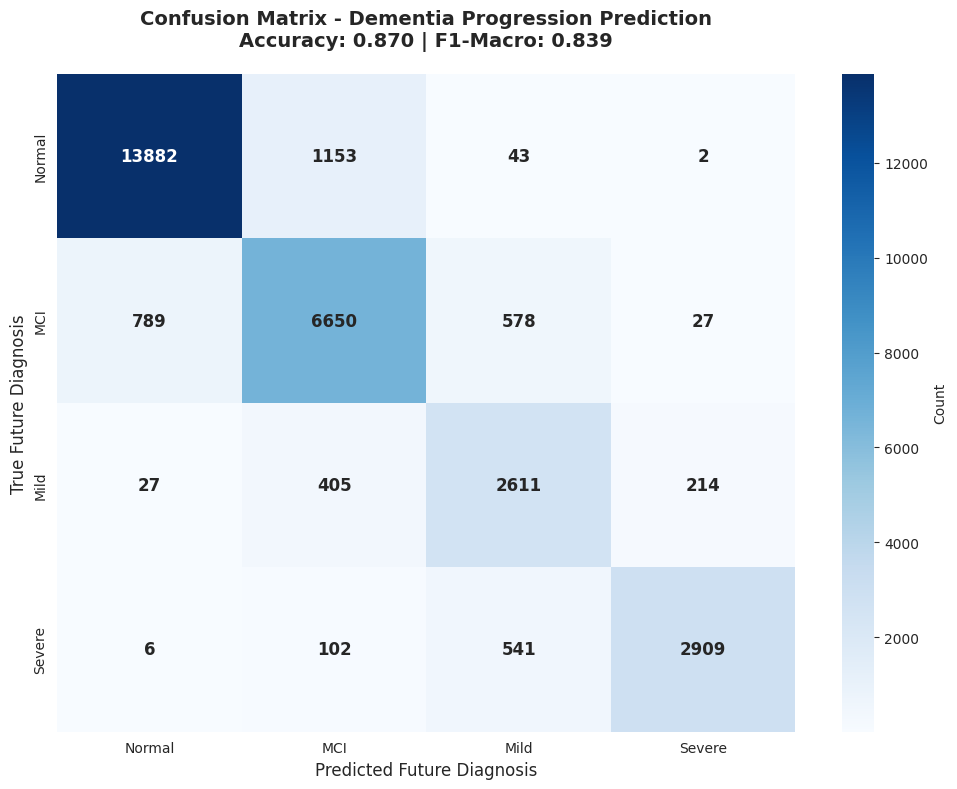

   ✅ Confusion matrix saved!


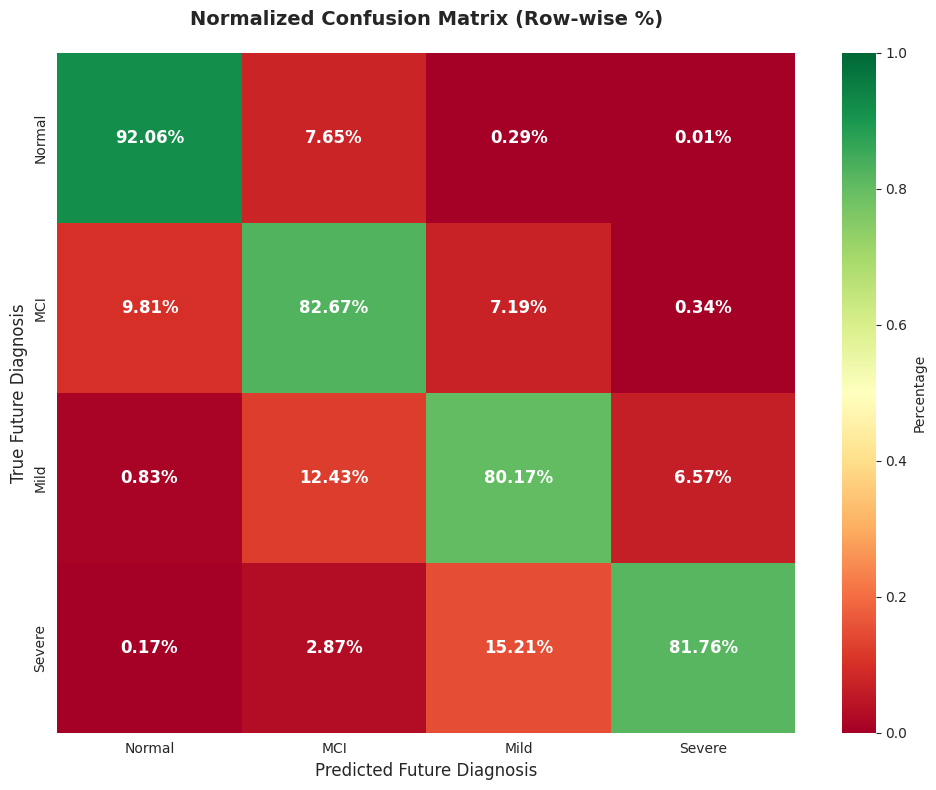

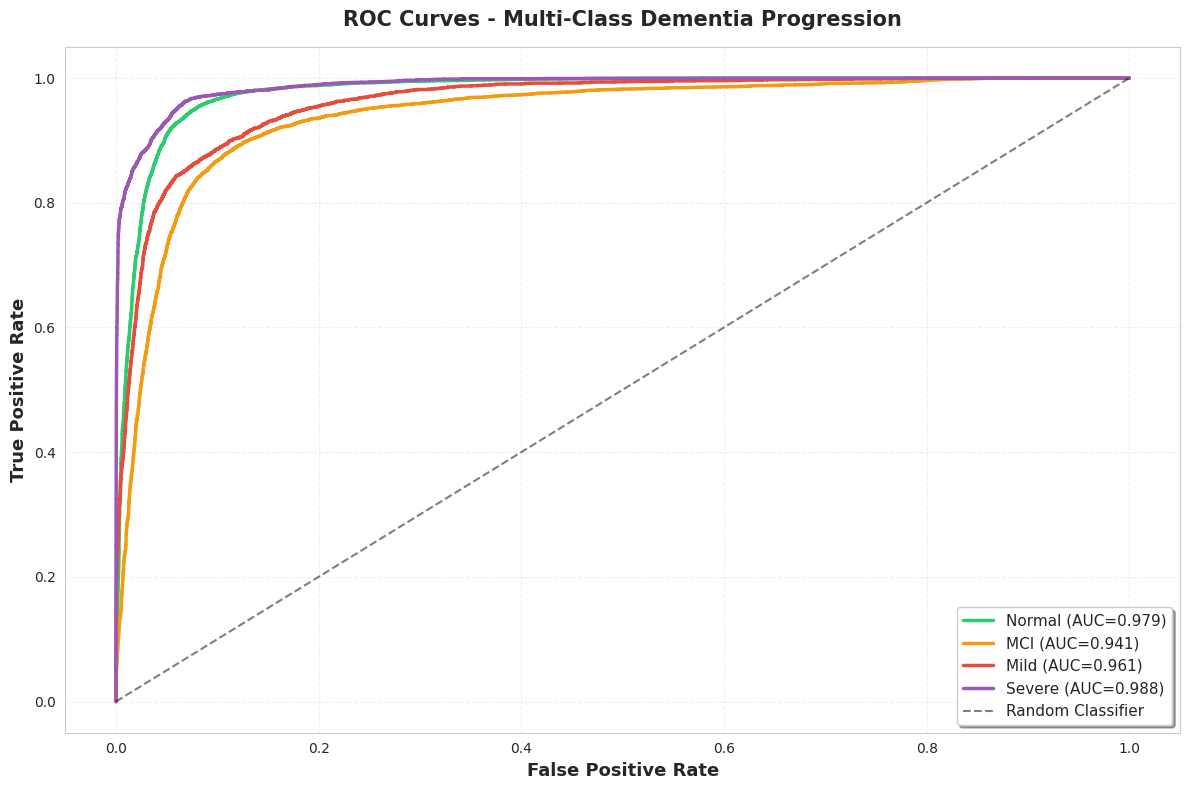

   ✅ ROC curves saved!

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.94      0.92      0.93     15080
         MCI       0.80      0.83      0.81      8044
        Mild       0.69      0.80      0.74      3257
      Severe       0.92      0.82      0.87      3558

    accuracy                           0.87     29939
   macro avg       0.84      0.84      0.84     29939
weighted avg       0.88      0.87      0.87     29939

   ✅ All basic visualizations complete!


In [10]:
# ============================================================================
# BLOCK 7: BASIC VISUALIZATIONS (CONFUSION MATRIX, ROC, METRICS) - SINGLE SPLIT
# ============================================================================
# Purpose: Create standard performance visualizations
# Adapted for Single Train-Test Split (No Cross-Validation plots)
# ============================================================================

Logger.section("Creating Performance Visualizations")

# Calculate overall metrics
final_acc = accuracy_score(y_true, y_pred)
final_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
final_f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)

Logger.success(f"Overall Accuracy: {final_acc:.4f}")
Logger.success(f"F1-Macro: {final_f1:.4f}")
Logger.success(f"F1-Weighted: {final_f1_weighted:.4f}")

Logger.info("\nPer-Class F1 Scores:")
for i, class_name in enumerate(Config.CLASS_NAMES):
    Logger.info(f"    {class_name}: {per_class_f1[i]:.4f}")

# === CONFUSION MATRIX ===
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=Config.CLASS_NAMES,
            yticklabels=Config.CLASS_NAMES,
            cbar_kws={'label': 'Count'},
            annot_kws={'size': 12, 'weight': 'bold'})

plt.title(f'Confusion Matrix - Dementia Progression Prediction\n' + 
          f'Accuracy: {final_acc:.3f} | F1-Macro: {final_f1:.3f}', 
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('True Future Diagnosis', fontsize=12)
plt.xlabel('Predicted Future Diagnosis', fontsize=12)
plt.tight_layout()
plt.savefig(f"{Config.OUTPUT_DIR}/confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

Logger.success("Confusion matrix saved!")

# === NORMALIZED CONFUSION MATRIX ===
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='RdYlGn',
            xticklabels=Config.CLASS_NAMES,
            yticklabels=Config.CLASS_NAMES,
            cbar_kws={'label': 'Percentage'},
            annot_kws={'size': 12, 'weight': 'bold'},
            vmin=0, vmax=1)

plt.title('Normalized Confusion Matrix (Row-wise %)', 
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('True Future Diagnosis', fontsize=12)
plt.xlabel('Predicted Future Diagnosis', fontsize=12)
plt.tight_layout()
plt.savefig(f"{Config.OUTPUT_DIR}/confusion_matrix_normalized.png", dpi=300, bbox_inches='tight')
plt.show()

# === ROC CURVES ===
y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])

plt.figure(figsize=(12, 8))
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']

for i in range(Config.N_CLASS):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{Config.CLASS_NAMES[i]} (AUC={auc_score:.3f})', 
             linewidth=2.5, color=colors[i])

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1.5, alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
plt.title('ROC Curves - Multi-Class Dementia Progression', fontsize=15, fontweight='bold', pad=15)
plt.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(f"{Config.OUTPUT_DIR}/roc_curves.png", dpi=300, bbox_inches='tight')
plt.show()

Logger.success("ROC curves saved!")

# === CLASSIFICATION REPORT ===
report = classification_report(y_true, y_pred, 
                               target_names=Config.CLASS_NAMES,
                               zero_division=0)

print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT")
print("="*80)
print(report)
print("="*80)

# Save report (Updated text for Single Split)
with open(f"{Config.OUTPUT_DIR}/classification_report.txt", 'w') as f:
    f.write("="*80 + "\n")
    f.write("DEMENTIA PROGRESSION PREDICTION - CLASSIFICATION REPORT\n")
    f.write("="*80 + "\n\n")
    f.write(f"Model: Ensemble (XGBoost + LightGBM + CatBoost)\n")
    f.write(f"Validation Strategy: Single Patient-Level Train-Test Split (80/20)\n")
    f.write(f"SMOTE: {Config.SMOTE_STRATEGY}\n\n")
    f.write(f"Overall Accuracy: {final_acc:.4f}\n")
    f.write(f"Overall F1-Macro: {final_f1:.4f}\n")
    f.write(f"Overall F1-Weighted: {final_f1_weighted:.4f}\n\n")
    f.write(report)

Logger.success("All basic visualizations complete!")

In [11]:
# ============================================================================
# BLOCK 8: SANKEY DIAGRAM (PROGRESSION FLOW) - Q1 REQUIREMENT
# ============================================================================
# Purpose: Visualize patient flow from current to predicted diagnosis
# Shows progression patterns - critical for dementia research papers
# ============================================================================

Logger.section("Creating Sankey Diagram - Clinical Progression Flow")

def plot_sankey(y_true, y_pred, class_names):
    """
    Create Sankey diagram showing flow from true to predicted diagnosis
    Left side: Ground truth (what actually happened)
    Right side: Model predictions
    """
    
    cm = confusion_matrix(y_true, y_pred)
    
    source = []
    target = []
    value = []
    link_colors = []
    
    # Define colors for each diagnosis
    node_colors = ['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']  # Green, Orange, Red, Purple
    
    for i in range(len(class_names)):  # True class (source)
        for j in range(len(class_names)):  # Predicted class (target)
            if cm[i, j] > 0:
                source.append(i)
                target.append(j + len(class_names))  # Offset for right side
                value.append(int(cm[i, j]))
                
                # Color links based on correctness
                if i == j:
                    # Correct prediction - green
                    link_colors.append('rgba(46, 204, 113, 0.4)')
                elif j > i:
                    # Predicted worse (over-prediction) - orange
                    link_colors.append('rgba(243, 156, 18, 0.4)')
                else:
                    # Predicted better (under-prediction) - red
                    link_colors.append('rgba(231, 76, 60, 0.4)')
    
    # Labels
    labels = [f"True: {c}" for c in class_names] + [f"Pred: {c}" for c in class_names]
    
    # Node colors
    all_node_colors = node_colors + node_colors
    
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=20,
            thickness=25,
            line=dict(color="black", width=1),
            label=labels,
            color=all_node_colors,
            customdata=[f"{labels[i]}" for i in range(len(labels))],
            hovertemplate='%{customdata}<br>Count: %{value}<extra></extra>'
        ),
        link=dict(
            source=source,
            target=target,
            value=value,
            color=link_colors,
            hovertemplate='%{source.label} → %{target.label}<br>Patients: %{value}<extra></extra>'
        )
    )])
    
    fig.update_layout(
        title={
            'text': "Clinical Progression Flow(Test Set): Ground Truth vs Model Predictions<br>" +
                    f"<sub>Total Predictions: {len(y_true):,} | Accuracy: {accuracy_score(y_true, y_pred):.1%}</sub>",
            'x': 0.5,
            'xanchor': 'center',
            'font': {'size': 18, 'color': '#2c3e50'}
        },
        font=dict(size=12, family="Arial"),
        height=600,
        margin=dict(l=20, r=20, t=100, b=20)
    )
    
    return fig

# Create Sankey
sankey_fig = plot_sankey(y_true, y_pred, Config.CLASS_NAMES)
sankey_fig.show()

# Save as HTML (interactive)
sankey_fig.write_html(f"{Config.OUTPUT_DIR}/sankey_progression_flow.html")

# Save as static image
try:
    sankey_fig.write_image(f"{Config.OUTPUT_DIR}/sankey_progression_flow.png", 
                           width=1400, height=600, scale=2)
    Logger.success("Sankey diagram saved (HTML + PNG)")
except:
    Logger.warning("PNG save failed (need kaleido), but HTML saved successfully")

# === PROGRESSION STATISTICS ===
Logger.info("\n📊 Progression Pattern Analysis:")

stable_count = (y_true == y_pred).sum()
progressed_count = (y_pred > y_true).sum()
improved_count = (y_pred < y_true).sum()

Logger.info(f"   Correctly predicted (Stable): {stable_count} ({stable_count/len(y_true)*100:.1f}%)")
Logger.info(f"   Over-predicted (Progression): {progressed_count} ({progressed_count/len(y_true)*100:.1f}%)")
Logger.info(f"   Under-predicted (Improvement): {improved_count} ({improved_count/len(y_true)*100:.1f}%)")

# Critical transitions
Logger.info("\n🔍 Critical Misclassification Patterns:")
for i in range(Config.N_CLASS):
    for j in range(Config.N_CLASS):
        if i != j and cm[i, j] > 0:
            pct = cm[i, j] / cm[i, :].sum() * 100
            if pct > 10:  # Only show significant confusions
                Logger.warning(f"   {Config.CLASS_NAMES[i]} → {Config.CLASS_NAMES[j]}: "
                             f"{cm[i, j]} cases ({pct:.1f}%)")

Logger.success("Sankey diagram complete!")


🚀 CREATING SANKEY DIAGRAM - CLINICAL PROGRESSION FLOW


   ⚠️  PNG save failed (need kaleido), but HTML saved successfully
   ℹ️  
📊 Progression Pattern Analysis:
   ℹ️     Correctly predicted (Stable): 26052 (87.0%)
   ℹ️     Over-predicted (Progression): 2017 (6.7%)
   ℹ️     Under-predicted (Improvement): 1870 (6.2%)
   ℹ️  
🔍 Critical Misclassification Patterns:
   ⚠️     Mild → MCI: 405 cases (12.4%)
   ⚠️     Severe → Mild: 541 cases (15.2%)
   ✅ Sankey diagram complete!



🚀 SHAP ANALYSIS - MODEL INTERPRETABILITY
   ℹ️  This may take a few minutes...
   ℹ️  Using Test Set for SHAP analysis (29939 samples)
   ℹ️  Sampling 300 instances from 29939 for faster computation...
   ✅ Using LightGBM for SHAP analysis (best compatibility)
   ℹ️  Computing SHAP values with LightGBM TreeExplainer...
   ✅ SHAP computation complete using LightGBM!
   ℹ️  
🔍 Inspecting SHAP values structure...
   ℹ️      SHAP values type: <class 'numpy.ndarray'>
   ✅ SHAP structure validated! Ready for visualization.
   ℹ️  Creating SHAP bar plot...


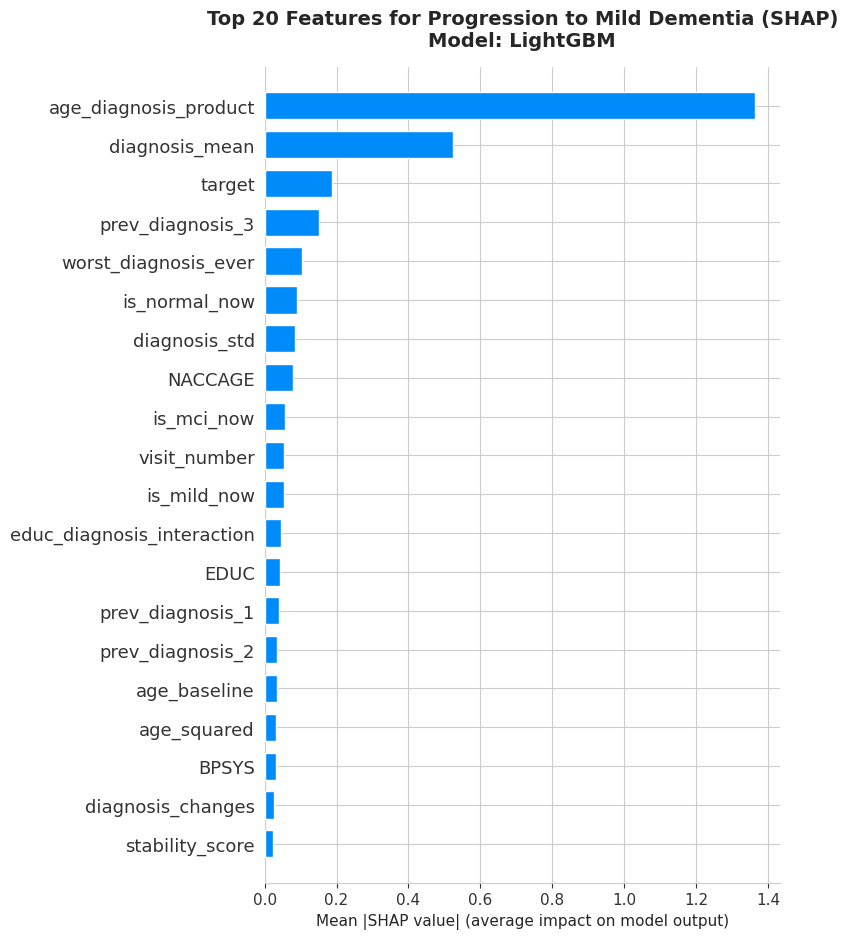

   ✅ Bar plot created!
   ℹ️  Creating SHAP beeswarm plot...


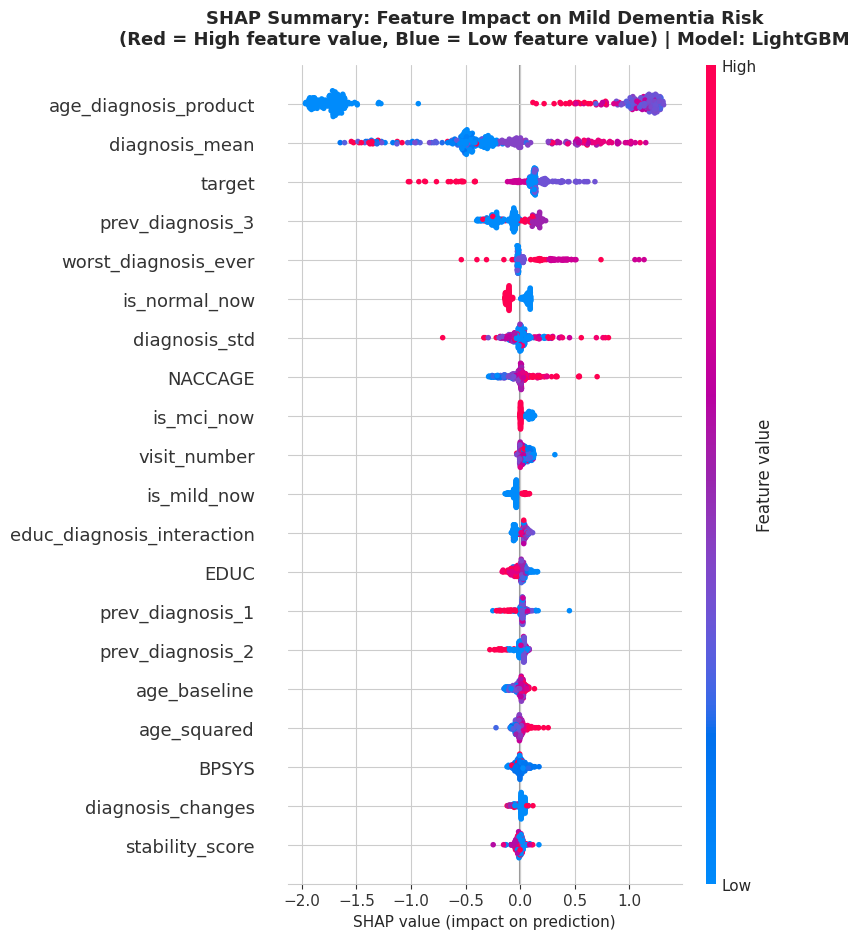

   ✅ Beeswarm plot created!
   ℹ️  
Creating SHAP comparison for all diagnostic classes...


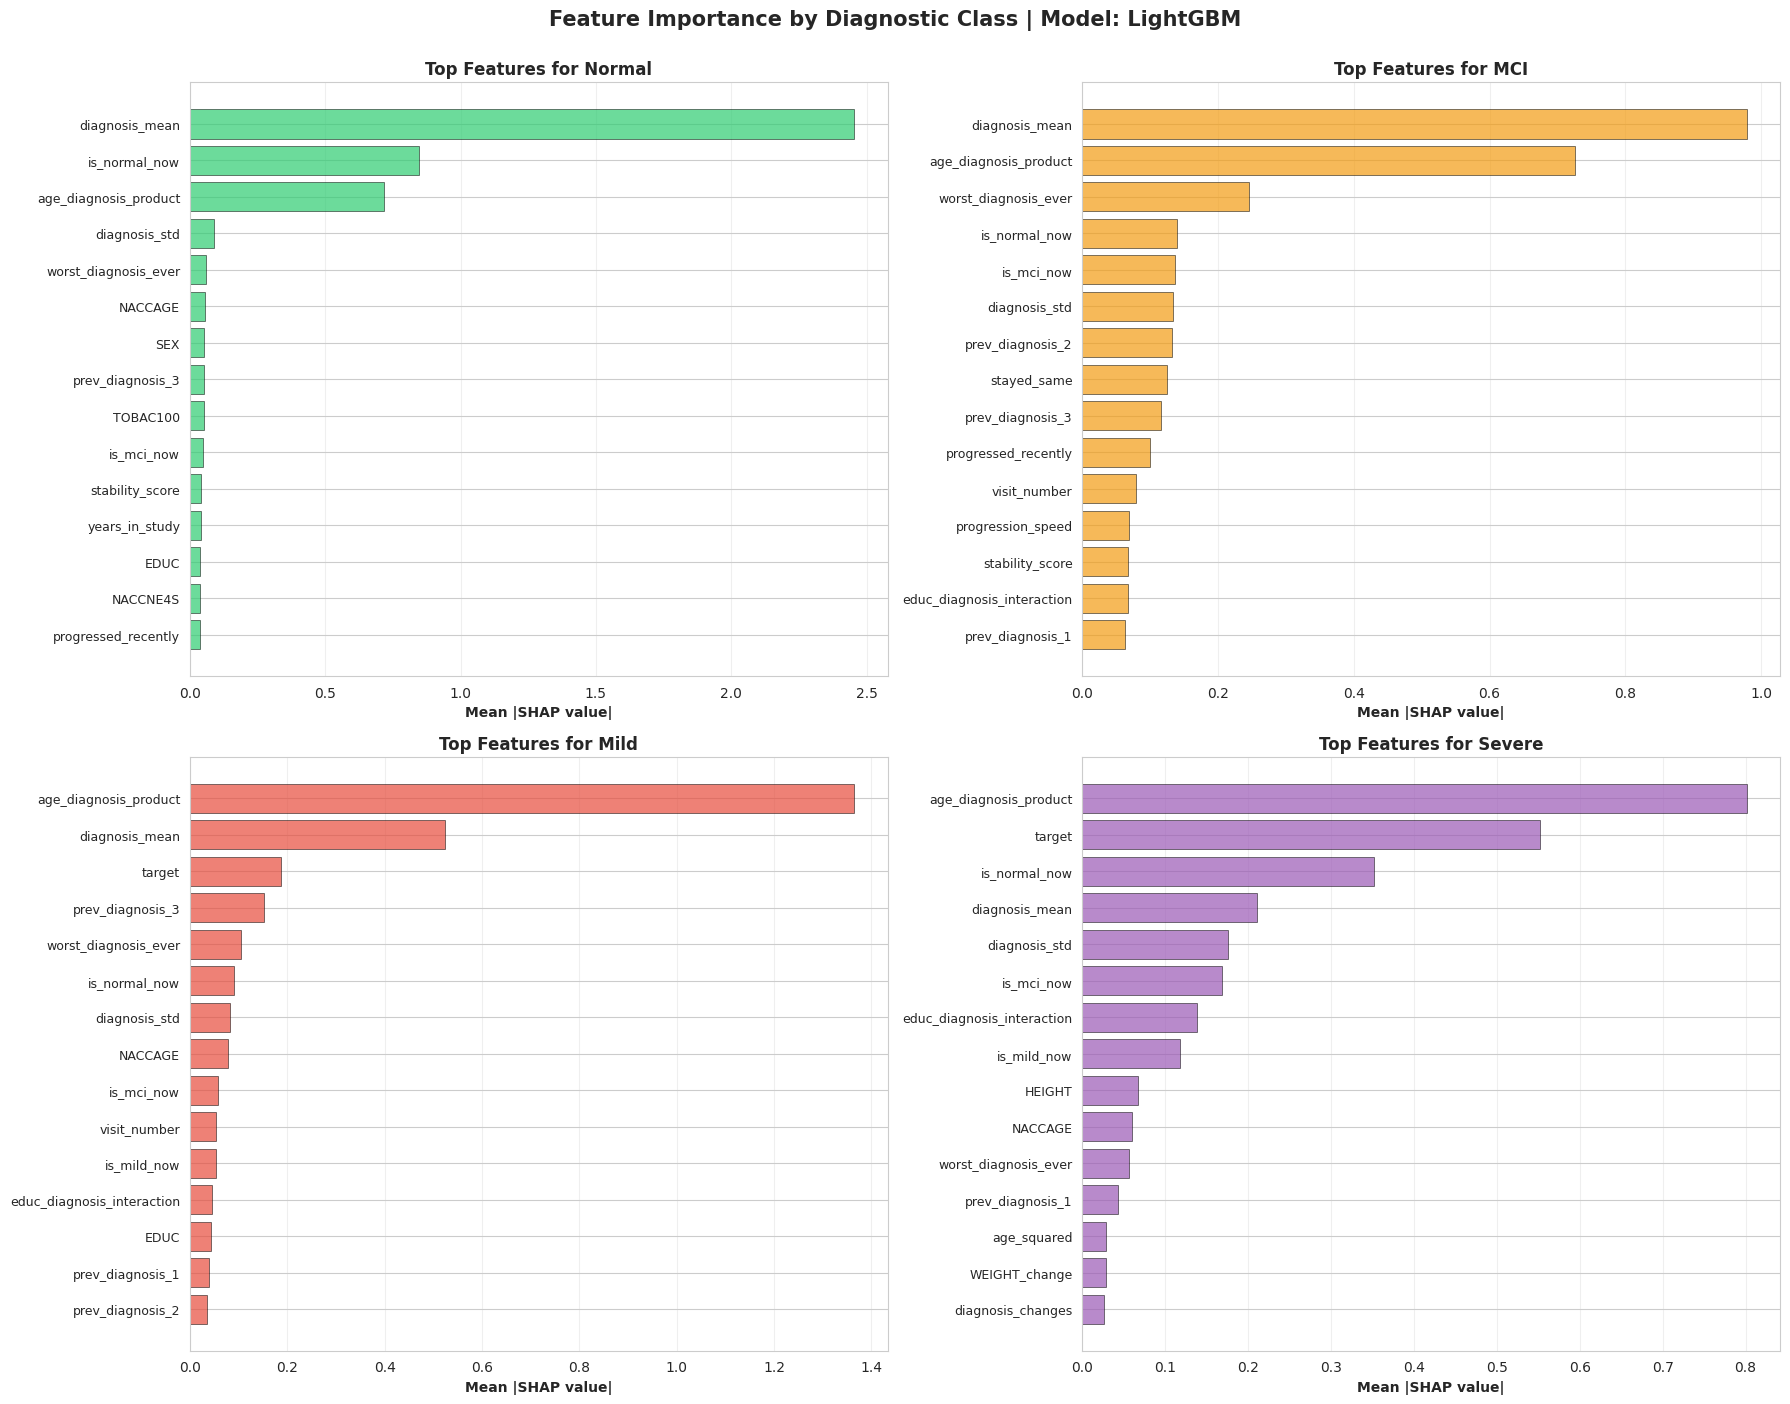

   ✅ All-classes comparison created!
   ℹ️  
📊 Creating top features comparison table...

TOP 5 FEATURES BY DIAGNOSTIC CLASS (SHAP Importance)
 Rank                        Normal                           MCI                          Mild                        Severe
    1        diagnosis_mean (2.455)        diagnosis_mean (0.979) age_diagnosis_product (1.365) age_diagnosis_product (0.801)
    2         is_normal_now (0.847) age_diagnosis_product (0.726)        diagnosis_mean (0.524)                target (0.552)
    3 age_diagnosis_product (0.717)  worst_diagnosis_ever (0.245)                target (0.187)         is_normal_now (0.352)
    4         diagnosis_std (0.090)         is_normal_now (0.140)      prev_diagnosis_3 (0.153)        diagnosis_mean (0.210)
    5  worst_diagnosis_ever (0.060)            is_mci_now (0.137)  worst_diagnosis_ever (0.105)         diagnosis_std (0.175)
   ✅ ================================================================================
   ✅ 🎉 SHAP ANA

In [12]:
# ============================================================================
# BLOCK 9: SHAP ANALYSIS (INTERPRETABILITY) - SINGLE SPLIT VERSION
# ============================================================================
# Purpose: Explain model predictions on the Test Set
# Shows which features drive predictions - critical for medical AI
# ============================================================================

Logger.section("SHAP Analysis - Model Interpretability")

Logger.info("This may take a few minutes...")

# === 1. PREPARE DATA (USE TEST SET FROM BLOCK 6) ===
# We use the X_test/y_test from Block 6 directly to explain model behavior
X_val_shap = X_test.copy()
y_val_shap = y_test.copy()

Logger.info(f"Using Test Set for SHAP analysis ({len(X_val_shap)} samples)")

# Sample data if too large (SHAP is computationally expensive)
# 300 samples is usually sufficient for a good global explanation
if len(X_val_shap) > 300:
    Logger.info(f"Sampling 300 instances from {len(X_val_shap)} for faster computation...")
    # Use consistent seed for reproducibility
    sample_idx = np.random.RandomState(Config.SEED).choice(len(X_val_shap), 300, replace=False)
    X_val_shap_sample = X_val_shap.iloc[sample_idx]
    y_val_shap_sample = y_val_shap.iloc[sample_idx]
else:
    X_val_shap_sample = X_val_shap
    y_val_shap_sample = y_val_shap

# === 2. SELECT MODEL FOR SHAP ===
shap_model = None
model_name = None

# Priority 1: LightGBM (Best SHAP compatibility)
if 'lgb' in final_ensemble.models:
    shap_model = final_ensemble.models['lgb']
    model_name = "LightGBM"
    Logger.success("Using LightGBM for SHAP analysis (best compatibility)")

# Priority 2: CatBoost
elif 'cat' in final_ensemble.models:
    shap_model = final_ensemble.models['cat']
    model_name = "CatBoost"
    Logger.success("Using CatBoost for SHAP analysis")

# Priority 3: XGBoost (with workaround for 2.x versions)
elif 'xgb' in final_ensemble.models:
    try:
        shap_model = final_ensemble.models['xgb']
        model_name = "XGBoost"
        Logger.info("Attempting XGBoost with SHAP workaround...")
        
        # Try with model_output parameter (helps SHAP understand format)
        explainer = shap.TreeExplainer(shap_model, X_val_shap_sample[:100], 
                                     model_output='raw')
        # Quick test
        test_shap = explainer.shap_values(X_val_shap_sample[:2])
        Logger.success("XGBoost SHAP workaround successful!")
        
    except Exception as e:
        Logger.warning(f"XGBoost SHAP failed: {str(e)[:100]}")
        Logger.warning("Will use approximate SHAP method instead")
        shap_model = None
        model_name = None

# === 3. COMPUTE SHAP VALUES ===
if shap_model is None:
    Logger.warning("⚠️  No tree model available for SHAP TreeExplainer")
    Logger.info("Using approximate SHAP (KernelExplainer) - this will be slower...")
    
    # Use KernelExplainer as fallback (model-agnostic)
    background = X_val_shap_sample[:50]  # Small background for speed
    
    # Wrapper for ensemble prediction
    def model_predict(X):
        return final_ensemble.predict_proba(X)
    
    explainer = shap.KernelExplainer(model_predict, background)
    shap_values = explainer.shap_values(X_val_shap_sample[:100])  # Limit to 100 for speed
    X_val_shap_sample = X_val_shap_sample[:100]
    model_name = "Ensemble (Approximate)"

else:
    # Calculate SHAP values with TreeExplainer
    try:
        Logger.info(f"Computing SHAP values with {model_name} TreeExplainer...")
        
        if model_name == "XGBoost":
            pass  # explainer already created above
        else:
            explainer = shap.TreeExplainer(shap_model)
        
        shap_values = explainer.shap_values(X_val_shap_sample)
        Logger.success(f"SHAP computation complete using {model_name}!")
        
    except Exception as e:
        Logger.warning(f"TreeExplainer failed: {str(e)[:100]}")
        Logger.info("Falling back to approximate method...")
        
        # Fallback to KernelExplainer
        background = X_val_shap_sample[:50]
        def model_predict(X):
            return shap_model.predict_proba(X)
        
        explainer = shap.KernelExplainer(model_predict, background)
        shap_values = explainer.shap_values(X_val_shap_sample[:100])
        X_val_shap_sample = X_val_shap_sample[:100]
        model_name = f"{model_name} (Approximate)"

# === 4. INSPECT STRUCTURE ===
Logger.info("\n🔍 Inspecting SHAP values structure...")

if isinstance(shap_values, list):
    Logger.info(f"    SHAP values type: list with {len(shap_values)} elements")
    # Verify shapes match
    for i, sv in enumerate(shap_values):
        if sv.shape != (len(X_val_shap_sample), len(X_val_shap_sample.columns)):
            Logger.warning(f"    ⚠️  Class {i} shape mismatch: {sv.shape}")
        else:
            pass # Shape is good
    
    # Extract Mild class (class 2) for later use
    mild_shap = shap_values[2]
    
else:
    Logger.info(f"    SHAP values type: {type(shap_values)}")
    # Handle 3D array format (samples, features, classes)
    if shap_values.ndim == 3:
        mild_shap = shap_values[:, :, 2]
    else:
        mild_shap = shap_values
        Logger.warning("    Unexpected SHAP format, using as-is")

Logger.success(f"SHAP structure validated! Ready for visualization.")

# === 5. GENERATE PLOTS ===

# A. SHAP BAR PLOT (Feature Importance for Mild Dementia)
Logger.info("Creating SHAP bar plot...")
try:
    plt.figure(figsize=(12, 8))
    shap.summary_plot(mild_shap, X_val_shap_sample, plot_type="bar", 
                      max_display=20, show=False)
    plt.title(f"Top 20 Features for Progression to Mild Dementia (SHAP)\nModel: {model_name}", 
             fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Mean |SHAP value| (average impact on model output)", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{Config.OUTPUT_DIR}/shap_importance_bar.png", dpi=300, bbox_inches='tight')
    plt.show()
    Logger.success("Bar plot created!")
except Exception as e:
    Logger.warning(f"Bar plot failed: {str(e)}")

# B. SHAP BEESWARM PLOT (Feature Impact Visualization)
Logger.info("Creating SHAP beeswarm plot...")
try:
    plt.figure(figsize=(12, 10))
    shap.summary_plot(mild_shap, X_val_shap_sample, max_display=20, show=False)
    plt.title(f"SHAP Summary: Feature Impact on Mild Dementia Risk\n" +
             f"(Red = High feature value, Blue = Low feature value) | Model: {model_name}", 
             fontsize=13, fontweight='bold', pad=15)
    plt.xlabel("SHAP value (impact on prediction)", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{Config.OUTPUT_DIR}/shap_beeswarm.png", dpi=300, bbox_inches='tight')
    plt.show()
    Logger.success("Beeswarm plot created!")
except Exception as e:
    Logger.warning(f"Beeswarm plot failed: {str(e)}")

# C. SHAP COMPARISON FOR ALL CLASSES (Side-by-Side)
Logger.info("\nCreating SHAP comparison for all diagnostic classes...")
try:
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    axes = axes.ravel()
    colors = ['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']

    for class_idx in range(Config.N_CLASS):
        ax = axes[class_idx]
        
        # Get SHAP values for this class
        if isinstance(shap_values, list):
            class_shap = shap_values[class_idx]
        else:
            class_shap = shap_values[:, :, class_idx] if shap_values.ndim == 3 else shap_values
        
        # Get top 15 features
        class_shap_importance = np.abs(class_shap).mean(axis=0)
        top_15_idx = np.argsort(class_shap_importance)[-15:]
        sorted_idx = top_15_idx[np.argsort(class_shap_importance[top_15_idx])]
        
        # Plot
        ax.barh(range(15), class_shap_importance[sorted_idx], 
                color=colors[class_idx], alpha=0.7, edgecolor='black', linewidth=0.5)
        ax.set_yticks(range(15))
        ax.set_yticklabels([X_val_shap_sample.columns[i] for i in sorted_idx], fontsize=9)
        ax.set_xlabel('Mean |SHAP value|', fontsize=10, fontweight='bold')
        ax.set_title(f'Top Features for {Config.CLASS_NAMES[class_idx]}', 
                    fontsize=12, fontweight='bold')
        ax.grid(alpha=0.3, axis='x')

    plt.suptitle(f'Feature Importance by Diagnostic Class | Model: {model_name}',
                fontsize=15, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(f"{Config.OUTPUT_DIR}/shap_all_classes.png", dpi=300, bbox_inches='tight')
    plt.show()
    Logger.success("All-classes comparison created!")
except Exception as e:
    Logger.warning(f"All-classes plot failed: {str(e)}")

# === 6. TOP FEATURES TABLE ===
Logger.info("\n📊 Creating top features comparison table...")
try:
    top_features_by_class = {}
    for class_idx in range(Config.N_CLASS):
        if isinstance(shap_values, list):
            class_shap = shap_values[class_idx]
        else:
            class_shap = shap_values[:, :, class_idx] if shap_values.ndim == 3 else shap_values
        
        class_shap_importance = np.abs(class_shap).mean(axis=0)
        top_5_idx = np.argsort(class_shap_importance)[-5:][::-1]
        top_features_by_class[Config.CLASS_NAMES[class_idx]] = [
            (X_val_shap_sample.columns[i], class_shap_importance[i]) 
            for i in top_5_idx
        ]

    comparison_data = []
    for rank in range(5):
        row = {'Rank': rank + 1}
        for class_name in Config.CLASS_NAMES:
            feat_name, feat_importance = top_features_by_class[class_name][rank]
            row[class_name] = f"{feat_name} ({feat_importance:.3f})"
        comparison_data.append(row)

    comparison_df = pd.DataFrame(comparison_data)

    print("\n" + "="*100)
    print("TOP 5 FEATURES BY DIAGNOSTIC CLASS (SHAP Importance)")
    print("="*100)
    print(comparison_df.to_string(index=False))
    print("="*100)

    comparison_df.to_csv(f"{Config.OUTPUT_DIR}/shap_features_comparison.csv", index=False)
except Exception as e:
    Logger.warning(f"Comparison table failed: {str(e)}")

Logger.success("="*80)
Logger.success("🎉 SHAP ANALYSIS COMPLETE!")
Logger.success("="*80)


🚀 CALIBRATION ANALYSIS - PREDICTION RELIABILITY


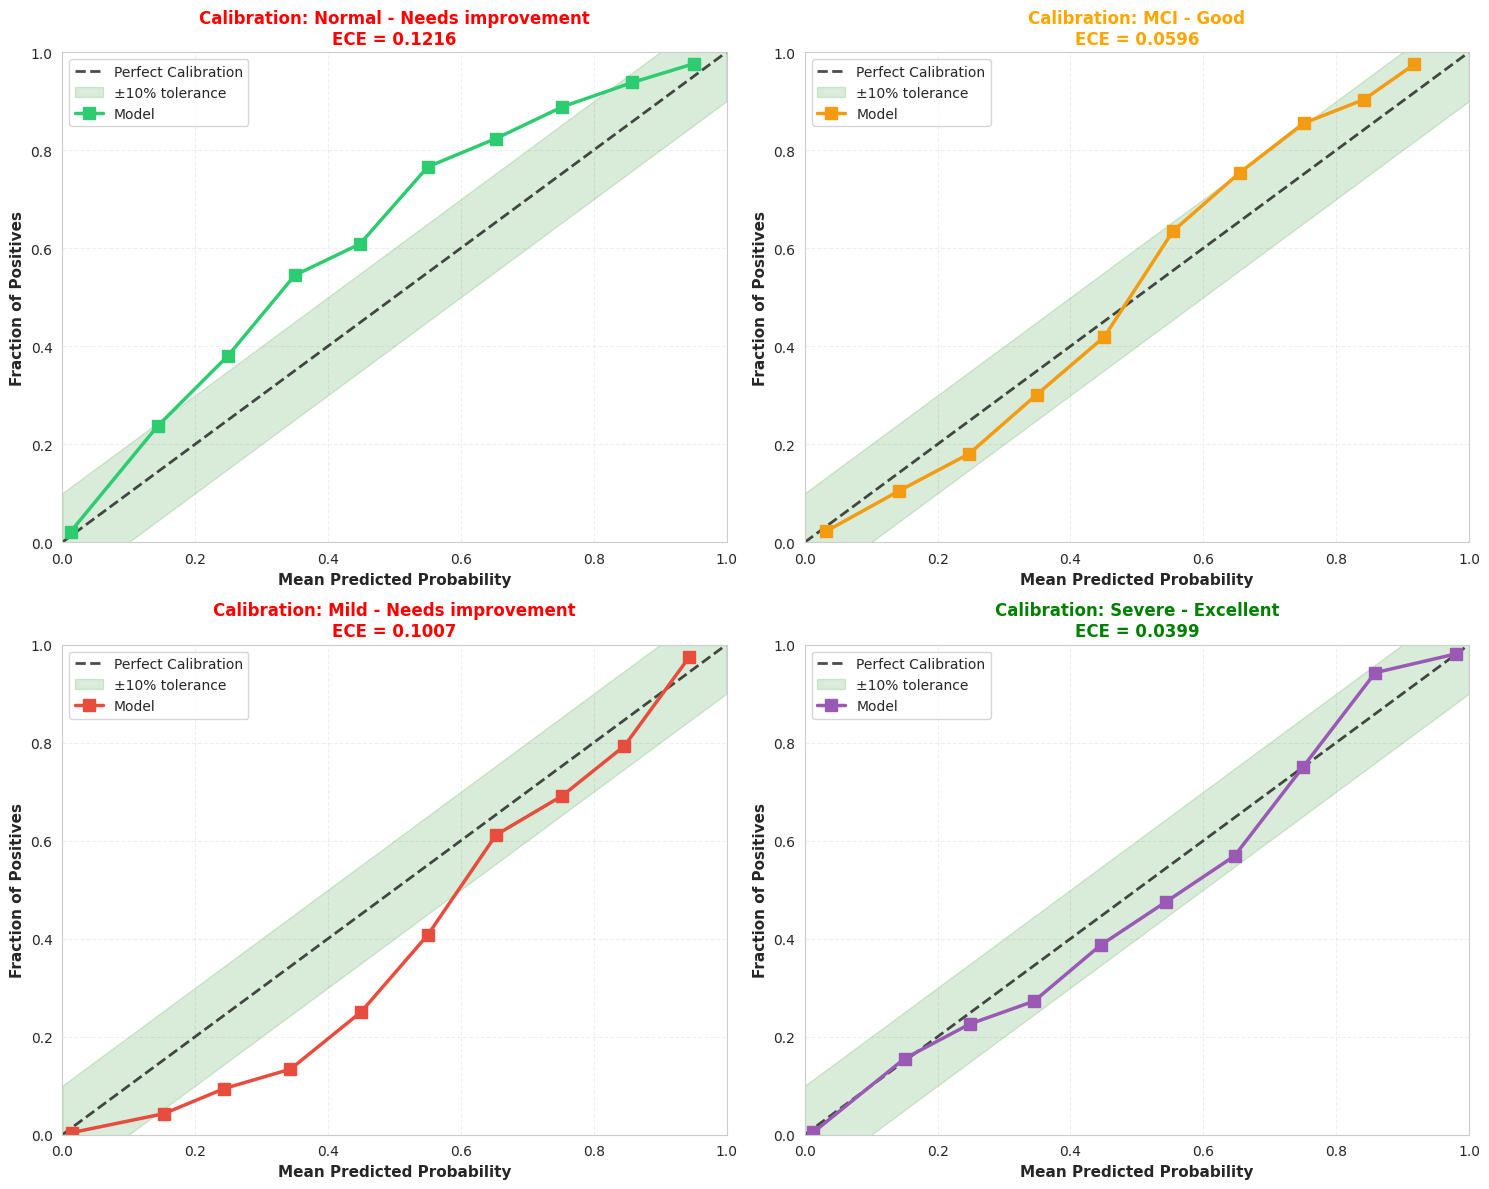

   ✅ Calibration analysis complete!
   ℹ️  Creating reliability diagram...


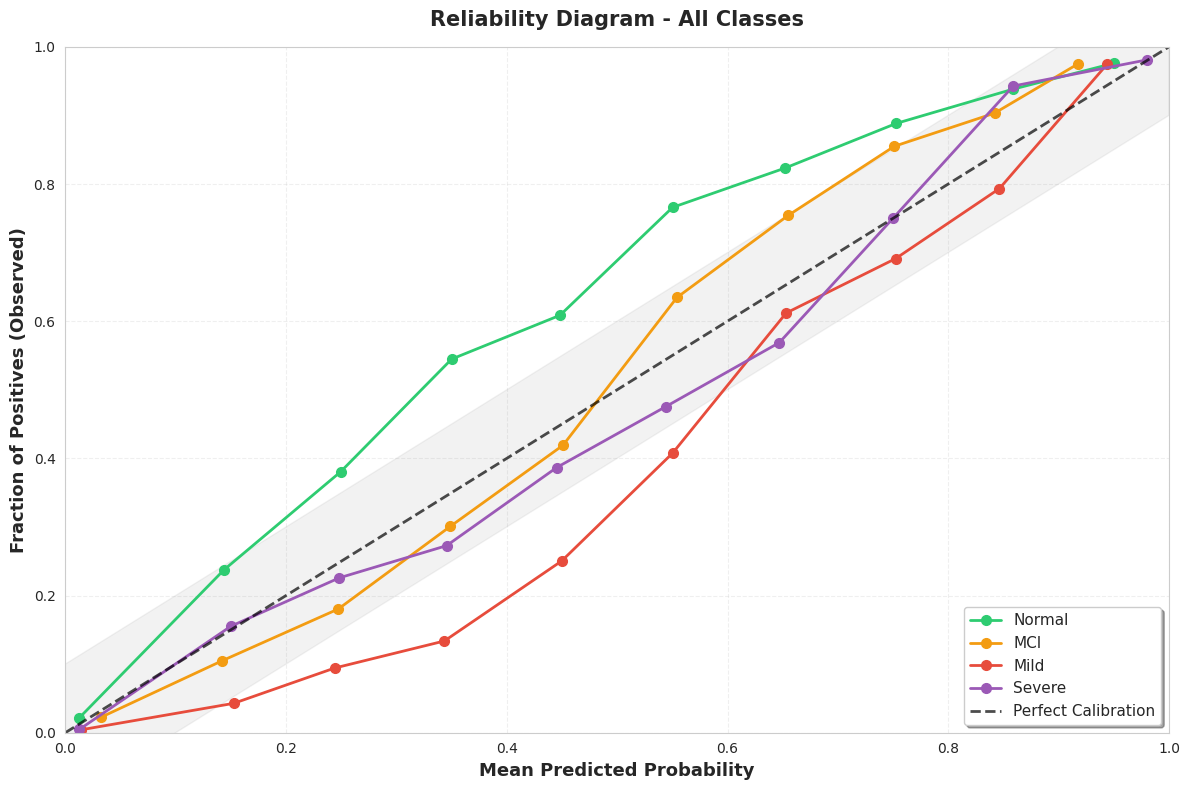

   ✅ Calibration visualizations complete!


In [13]:
# ============================================================================
# BLOCK 10: CALIBRATION CURVES - Q1 REQUIREMENT
# ============================================================================
# Purpose: Assess prediction reliability (calibration)
# If model says "70% chance", do 70% actually progress? Critical for clinical use
# ============================================================================

Logger.section("Calibration Analysis - Prediction Reliability")

from sklearn.calibration import calibration_curve
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']

for class_idx in range(Config.N_CLASS):
    ax = axes[class_idx]
    
    # Get probabilities for this class
    y_true_binary = (y_true == class_idx).astype(int)
    y_prob_class = y_proba[:, class_idx]
    
    # Calculate calibration curve
    try:
        fraction_of_positives, mean_predicted_value = calibration_curve(
            y_true_binary, y_prob_class, n_bins=10, strategy='uniform'
        )
        
        # Perfect calibration line (plot first so it's behind)
        ax.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', linewidth=2, alpha=0.7)
        
        # Shaded tolerance region (±10%) - FIXED: Single fill_between
        x_line = np.array([0, 1])
        y_line = np.array([0, 1])
        tolerance = 0.1
        ax.fill_between(x_line, y_line - tolerance, y_line + tolerance,
                        alpha=0.15, color='green', label='±10% tolerance')
        
        # Plot calibration curve on top
        ax.plot(mean_predicted_value, fraction_of_positives, 's-', 
               linewidth=2.5, markersize=8, label='Model', color=colors[class_idx])
        
        # Calculate calibration error (ECE - Expected Calibration Error)
        ece = np.mean(np.abs(fraction_of_positives - mean_predicted_value))
        
        # Add interpretation text with color-coded title
        if ece < 0.05:
            calibration_text = "Excellent"
            text_color = 'green'
        elif ece < 0.10:
            calibration_text = "Good"
            text_color = 'orange'
        else:
            calibration_text = "Needs improvement"
            text_color = 'red'
        
        ax.set_xlabel('Mean Predicted Probability', fontsize=11, fontweight='bold')
        ax.set_ylabel('Fraction of Positives', fontsize=11, fontweight='bold')
        ax.set_title(f'Calibration: {Config.CLASS_NAMES[class_idx]} - {calibration_text}\nECE = {ece:.4f}', 
                    fontsize=12, fontweight='bold', color=text_color)
        ax.legend(loc='upper left', fontsize=10)
        ax.grid(alpha=0.3, linestyle='--')
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
        
    except Exception as e:
        ax.text(0.5, 0.5, f'Insufficient data\nfor class {Config.CLASS_NAMES[class_idx]}', 
               ha='center', va='center', fontsize=12, color='red')
        ax.set_title(f'{Config.CLASS_NAMES[class_idx]}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{Config.OUTPUT_DIR}/calibration_curves.png", dpi=300, bbox_inches='tight')
plt.show()

Logger.success("Calibration analysis complete!")

# === RELIABILITY DIAGRAM (ALTERNATIVE VISUALIZATION) ===
Logger.info("Creating reliability diagram...")

fig, ax = plt.subplots(figsize=(12, 8))

for class_idx in range(Config.N_CLASS):
    y_true_binary = (y_true == class_idx).astype(int)
    y_prob_class = y_proba[:, class_idx]
    
    try:
        fraction_of_positives, mean_predicted_value = calibration_curve(
            y_true_binary, y_prob_class, n_bins=10
        )
        
        ax.plot(mean_predicted_value, fraction_of_positives, 'o-', 
               linewidth=2, markersize=7, label=Config.CLASS_NAMES[class_idx],
               color=colors[class_idx])
    except:
        pass

# Perfect calibration reference
ax.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', linewidth=2, alpha=0.7)

# Optional: Add tolerance band here too
x_line = np.array([0, 1])
y_line = np.array([0, 1])
tolerance = 0.1
ax.fill_between(x_line, y_line - tolerance, y_line + tolerance,
                alpha=0.1, color='gray')

ax.set_xlabel('Mean Predicted Probability', fontsize=13, fontweight='bold')
ax.set_ylabel('Fraction of Positives (Observed)', fontsize=13, fontweight='bold')
ax.set_title('Reliability Diagram - All Classes', fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
ax.grid(alpha=0.3, linestyle='--')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig(f"{Config.OUTPUT_DIR}/reliability_diagram.png", dpi=300, bbox_inches='tight')
plt.show()

Logger.success("Calibration visualizations complete!")

In [14]:
# Quick script to check races in dataframe
import pandas as pd

# Race code mapping (NACC standard)
race_names = {
    1: 'White',
    2: 'Black/African American',
    3: 'American Indian/Alaska Native',
    4: 'Native Hawaiian/Pacific Islander',
    5: 'Asian',
    50: 'Other/Multiracial',
    99: 'Unknown'
}

print("="*60)
print("RACE DISTRIBUTION IN DATAFRAME")
print("="*60)

if 'RACE' in df_original.columns:
    # Get value counts
    race_counts = df_original['RACE'].value_counts().sort_index()
    
    print(f"\nTotal samples: {len(df_original)}")
    print(f"Non-null RACE values: {df_original['RACE'].notna().sum()}")
    print(f"\nUnique race codes: {df_original['RACE'].nunique()}")
    print("\nRace Distribution:")
    print("-"*60)
    
    for race_code, count in race_counts.items():
        race_name = race_names.get(race_code, f"Unknown code {race_code}")
        percentage = (count / len(df_original)) * 100
        print(f"  [{race_code}] {race_name:30s}: {count:6d} ({percentage:5.2f}%)")
    
    # Check for missing values
    missing = df_original['RACE'].isna().sum()
    if missing > 0:
        percentage = (missing / len(df_original)) * 100
        print(f"  [--] Missing/NaN values          : {missing:6d} ({percentage:5.2f}%)")
    
    print("\n" + "="*60)
    
    # Summary for fairness analysis
    valid_races = race_counts[race_counts >= 10]  # At least 10 samples
    print(f"\nRaces with ≥10 samples (for fairness analysis): {len(valid_races)}")
    for race_code in valid_races.index:
        print(f"  - {race_names.get(race_code, f'Code {race_code}')}")
    
else:
    print("\n❌ Column 'RACE' not found in dataframe!")
    print(f"\nAvailable columns: {list(df_original.columns)}")

RACE DISTRIBUTION IN DATAFRAME

Total samples: 150904
Non-null RACE values: 150904

Unique race codes: 7

Race Distribution:
------------------------------------------------------------
  [1] White                         : 124728 (82.65%)
  [2] Black/African American        :  19440 (12.88%)
  [3] American Indian/Alaska Native :    861 ( 0.57%)
  [4] Native Hawaiian/Pacific Islander:    107 ( 0.07%)
  [5] Asian                         :   3771 ( 2.50%)
  [50] Other/Multiracial             :   1525 ( 1.01%)
  [99] Unknown                       :    472 ( 0.31%)


Races with ≥10 samples (for fairness analysis): 7
  - White
  - Black/African American
  - American Indian/Alaska Native
  - Native Hawaiian/Pacific Islander
  - Asian
  - Other/Multiracial
  - Unknown



🚀 DEMOGRAPHIC FAIRNESS & BIAS ANALYSIS
   ✅ ✓ Found saved test indices (29939 samples)
   ✅ ✓ Successfully aligned predictions with demographic data
   ℹ️  
📊 Performance by SEX:
   ℹ️      Male (n=12683): Acc=0.8596, F1=0.8439
   ℹ️      Female (n=17256): Acc=0.8780, F1=0.8311


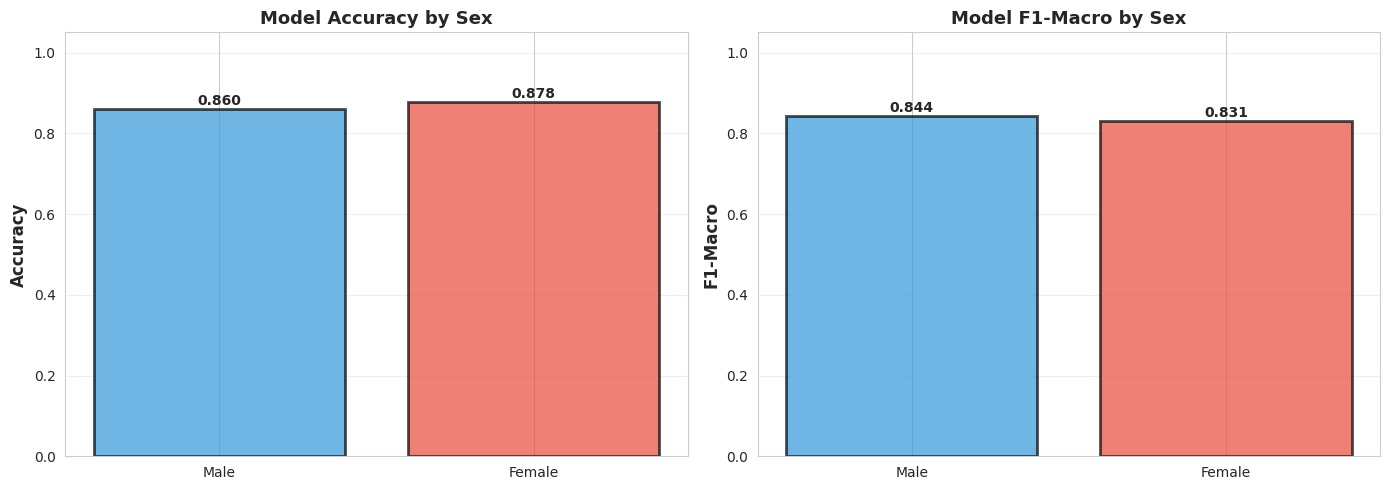

   ℹ️  
📊 Performance by Age Group:
   ℹ️  
📊 Performance by age_group:
   ℹ️      Group 65-74 (n=10696): Acc=0.8908, F1=0.8498
   ℹ️      Group 75-84 (n=10424): Acc=0.8518, F1=0.8290
   ℹ️      Group 85+ (n=3576): Acc=0.8272, F1=0.8130
   ℹ️      Group <65 (n=5243): Acc=0.8940, F1=0.8557


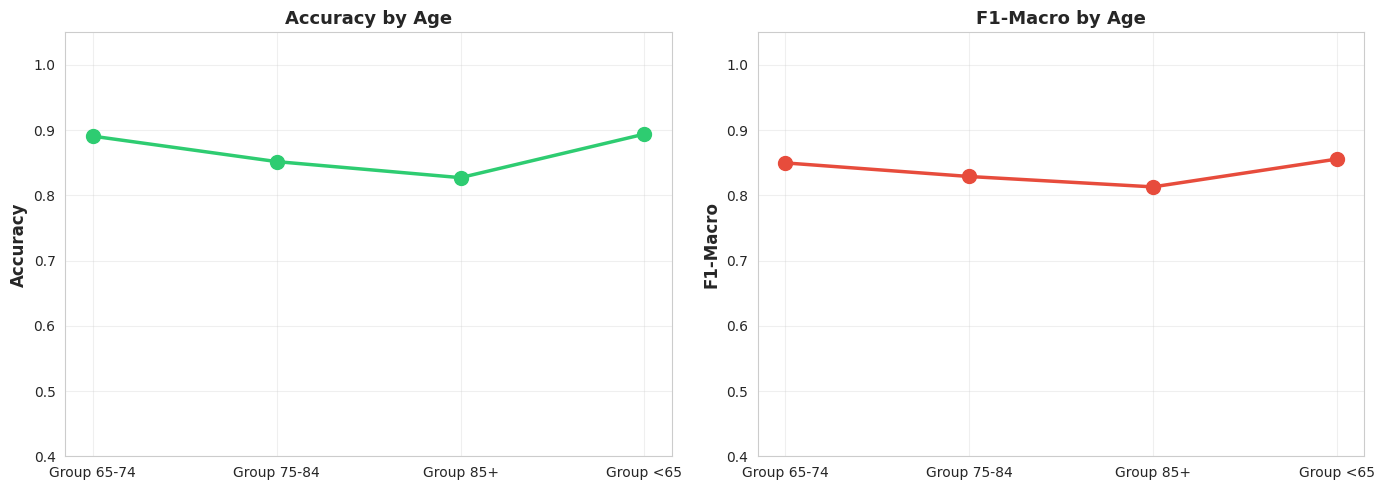

   ℹ️  
📊 Performance by RACE:
   ℹ️      White (n=24826): Acc=0.8715, F1=0.8400
   ℹ️      Black/African American (n=3723): Acc=0.8638, F1=0.8214
   ℹ️      American Indian/Alaska Native (n=190): Acc=0.8579, F1=0.8117
   ℹ️      Native Hawaiian/Pacific Islander (n=13): Acc=0.9231, F1=0.8939
   ℹ️      Asian (n=791): Acc=0.8597, F1=0.8319
   ℹ️      Other/Multiracial (n=286): Acc=0.8671, F1=0.8579
   ℹ️      Unknown (n=110): Acc=0.8727, F1=0.8511
   ✅ Race-based performance analysis saved
   ✅ ✓ Fairness acceptable (Disparity: 0.065)
   ✅ Demographic fairness analysis complete!


In [15]:
# ============================================================================
# BLOCK 11: DEMOGRAPHIC FAIRNESS ANALYSIS (SINGLE SPLIT VERSION)
# ============================================================================
# Purpose: Check if model works equally well for all groups (Sex, Age, Race)
# Critical for medical AI ethics and publication
# ============================================================================

Logger.section("Demographic Fairness & Bias Analysis")

# ============================================================================
# 1. RECONSTRUCT DATAFRAME FOR TEST SET
# ============================================================================
# We need to link predictions (y_pred) back to demographics (Age, Sex, etc.)
# In Block 6, we saved 'test_indices' for exactly this purpose.

if 'test_indices' in locals():
    Logger.success(f"✓ Found saved test indices ({len(test_indices)} samples)")
    
    # 1. Get original demographic data for the test set
    df_aligned = df_original.loc[test_indices].copy()
    
    # 2. Attach Truth and Predictions
    # NOTE: We must ensure lengths match
    if len(df_aligned) == len(y_true):
        df_aligned['y_true'] = y_true.values if hasattr(y_true, 'values') else y_true
        df_aligned['y_pred'] = y_pred
        Logger.success("✓ Successfully aligned predictions with demographic data")
    else:
        Logger.error(f"❌ Length mismatch: demographics={len(df_aligned)}, preds={len(y_true)}")
        # Fallback: Try to use the index of y_true if it's a Series
        if hasattr(y_true, 'index'):
            Logger.info("Attempting alignment via y_true index...")
            df_aligned = df_original.loc[y_true.index].copy()
            df_aligned['y_true'] = y_true.values
            df_aligned['y_pred'] = y_pred
            Logger.success("✓ Alignment recovered via y_true index")
        else:
            raise ValueError("Critical alignment failure for fairness analysis")
else:
    # Emergency Fallback if you restarted the kernel and lost variables
    Logger.warning("⚠️  'test_indices' not found. Using y_true index as fallback...")
    if hasattr(y_true, 'index'):
        df_aligned = df_original.loc[y_true.index].copy()
        df_aligned['y_true'] = y_true.values
        df_aligned['y_pred'] = y_pred
    else:
        Logger.error("❌ Cannot reconstruct demographics. Skipping fairness analysis.")
        df_aligned = pd.DataFrame() # Empty to skip

# ============================================================================
# 2. FAIRNESS CHECKER FUNCTION
# ============================================================================

def check_bias_across_groups(df_aligned, group_col, group_names=None):
    """
    Check model performance across demographic groups
    """
    if df_aligned.empty or group_col not in df_aligned.columns:
        Logger.warning(f"Column {group_col} not found or dataframe empty, skipping...")
        return None
    
    Logger.info(f"\n📊 Performance by {group_col}:")
    
    results = []
    # Get unique groups, handling NaNs
    unique_groups = sorted([g for g in df_aligned[group_col].unique() if pd.notna(g)])
    
    for g in unique_groups:
        mask = (df_aligned[group_col] == g)
        if mask.sum() < 5:  # Skip if fewer than 5 samples (statistically insignificant)
            continue
        
        group_true = df_aligned.loc[mask, 'y_true'].values
        group_pred = df_aligned.loc[mask, 'y_pred'].values
        
        acc = accuracy_score(group_true, group_pred)
        f1 = f1_score(group_true, group_pred, average='macro', zero_division=0)
        
        group_name = group_names.get(g, f"Group {g}") if group_names else f"Group {g}"
        
        Logger.info(f"    {group_name} (n={mask.sum()}): Acc={acc:.4f}, F1={f1:.4f}")
        
        results.append({
            'Group': group_name,
            'N': mask.sum(),
            'Accuracy': acc,
            'F1-Macro': f1
        })
    
    if not results:
        return None
        
    return pd.DataFrame(results)

# ============================================================================
# 3. RUN ANALYSES (SEX, AGE, RACE)
# ============================================================================

# --- A. SEX-BASED ANALYSIS ---
sex_names = {1: 'Male', 2: 'Female'}
sex_results = check_bias_across_groups(df_aligned, 'SEX', sex_names)

if sex_results is not None and len(sex_results) > 0:
    # Visualize
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.bar(sex_results['Group'], sex_results['Accuracy'], 
           color=['#3498db', '#e74c3c'], alpha=0.7, edgecolor='black', linewidth=2)
    ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax1.set_title('Model Accuracy by Sex', fontsize=13, fontweight='bold')
    ax1.set_ylim([0, 1.05])
    ax1.grid(alpha=0.3, axis='y')
    
    for i, row in sex_results.iterrows():
        ax1.text(i, row['Accuracy'] + 0.01, f"{row['Accuracy']:.3f}", 
                ha='center', fontweight='bold')
    
    ax2.bar(sex_results['Group'], sex_results['F1-Macro'], 
           color=['#3498db', '#e74c3c'], alpha=0.7, edgecolor='black', linewidth=2)
    ax2.set_ylabel('F1-Macro', fontsize=12, fontweight='bold')
    ax2.set_title('Model F1-Macro by Sex', fontsize=13, fontweight='bold')
    ax2.set_ylim([0, 1.05])
    ax2.grid(alpha=0.3, axis='y')
    
    for i, row in sex_results.iterrows():
        ax2.text(i, row['F1-Macro'] + 0.01, f"{row['F1-Macro']:.3f}", 
                ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(f"{Config.OUTPUT_DIR}/fairness_by_sex.png", dpi=300, bbox_inches='tight')
    plt.show()

# --- B. AGE-BASED ANALYSIS ---
if 'NACCAGE' in df_aligned.columns:
    Logger.info("\n📊 Performance by Age Group:")
    
    # Create age bins
    df_aligned['age_group'] = pd.cut(df_aligned['NACCAGE'], 
                                    bins=[0, 65, 75, 85, 120],
                                    labels=['<65', '65-74', '75-84', '85+'])
    
    age_results = check_bias_across_groups(df_aligned, 'age_group')
    
    if age_results is not None and len(age_results) > 0:
        # Visualize
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        axes[0].plot(age_results['Group'], age_results['Accuracy'], 
                    'o-', linewidth=2.5, markersize=10, color='#2ecc71')
        axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
        axes[0].set_title('Accuracy by Age', fontsize=13, fontweight='bold')
        axes[0].grid(alpha=0.3)
        axes[0].set_ylim([0.4, 1.05])
        
        axes[1].plot(age_results['Group'], age_results['F1-Macro'], 
                    'o-', linewidth=2.5, markersize=10, color='#e74c3c')
        axes[1].set_ylabel('F1-Macro', fontsize=12, fontweight='bold')
        axes[1].set_title('F1-Macro by Age', fontsize=13, fontweight='bold')
        axes[1].grid(alpha=0.3)
        axes[1].set_ylim([0.4, 1.05])
        
        plt.tight_layout()
        plt.savefig(f"{Config.OUTPUT_DIR}/fairness_by_age.png", dpi=300, bbox_inches='tight')
        plt.show()

# --- C. RACE-BASED ANALYSIS ---
if 'RACE' in df_aligned.columns:
    race_names = {
        1: 'White', 2: 'Black/African American', 3: 'American Indian/Alaska Native',
        4: 'Native Hawaiian/Pacific Islander', 5: 'Asian', 50: 'Other/Multiracial', 99: 'Unknown'
    }
    
    race_results = check_bias_across_groups(df_aligned, 'RACE', race_names)
    
    if race_results is not None and len(race_results) > 1:
        race_results.to_csv(f"{Config.OUTPUT_DIR}/fairness_by_race.csv", index=False)
        Logger.success("Race-based performance analysis saved")
        
        # Check disparities
        max_acc = race_results['Accuracy'].max()
        min_acc = race_results['Accuracy'].min()
        disparity = max_acc - min_acc
        
        if disparity > 0.10: # >10% difference
            Logger.warning(f"⚠️  Accuracy disparity detected: {disparity:.3f}")
        else:
            Logger.success(f"✓ Fairness acceptable (Disparity: {disparity:.3f})")

# ============================================================================
# 4. SAVE REPORT
# ============================================================================
fairness_summary = []
if sex_results is not None and len(sex_results) > 0: fairness_summary.append(("Sex", sex_results))
if 'age_results' in locals() and age_results is not None: fairness_summary.append(("Age", age_results))
if 'race_results' in locals() and race_results is not None: fairness_summary.append(("Race", race_results))

if fairness_summary:
    with open(f"{Config.OUTPUT_DIR}/fairness_analysis.txt", 'w') as f:
        f.write("="*80 + "\n")
        f.write("DEMOGRAPHIC FAIRNESS ANALYSIS (TEST SET)\n")
        f.write("="*80 + "\n\n")
        for group_name, results_df in fairness_summary:
            f.write(f"\n{group_name}-based Performance:\n")
            f.write("-" * 40 + "\n")
            f.write(results_df.to_string(index=False))
            f.write("\n\n")

Logger.success("Demographic fairness analysis complete!")


🚀 ERROR ANALYSIS - UNDERSTANDING MODEL FAILURES
   ℹ️  Total predictions: 29939
   ℹ️  Correct: 26052 (87.0%)
   ℹ️  Misclassified: 3887 (13.0%)
   ℹ️  
📊 Errors by True Class:
   ℹ️     Normal: 1198/15080 errors (7.9%)
   ℹ️     MCI: 1394/8044 errors (17.3%)
   ℹ️     Mild: 646/3257 errors (19.8%)
   ℹ️     Severe: 649/3558 errors (18.2%)


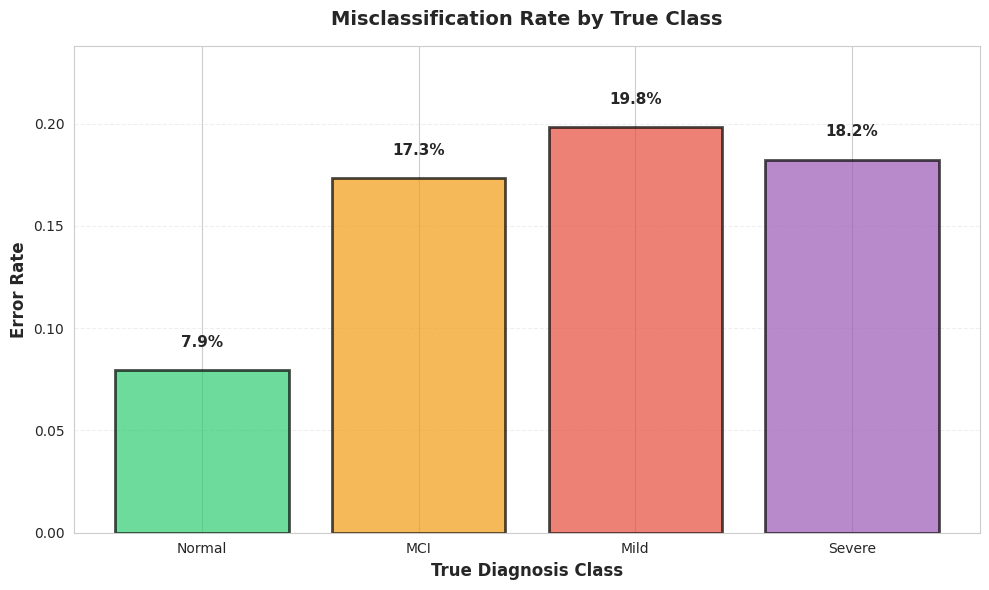

   ℹ️  
🔍 Most Common Confusion Patterns:

TOP 10 CONFUSION PATTERNS
  True Predicted  Count  Percentage
Normal       MCI   1153    7.645889
   MCI    Normal    789    9.808553
   MCI      Mild    578    7.185480
Severe      Mild    541   15.205171
  Mild       MCI    405   12.434756
  Mild    Severe    214    6.570464
Severe       MCI    102    2.866779
Normal      Mild     43    0.285146
  Mild    Normal     27    0.828984
   MCI    Severe     27    0.335654
   ℹ️  
⚠️  Error Severity Analysis:
   ℹ️  Error severity (how far off):
   ℹ️     1 stage off: 3680 (94.7%)
   ℹ️     2 stages off: 199 (5.1%)
   ℹ️     3 stages off: 8 (0.2%)


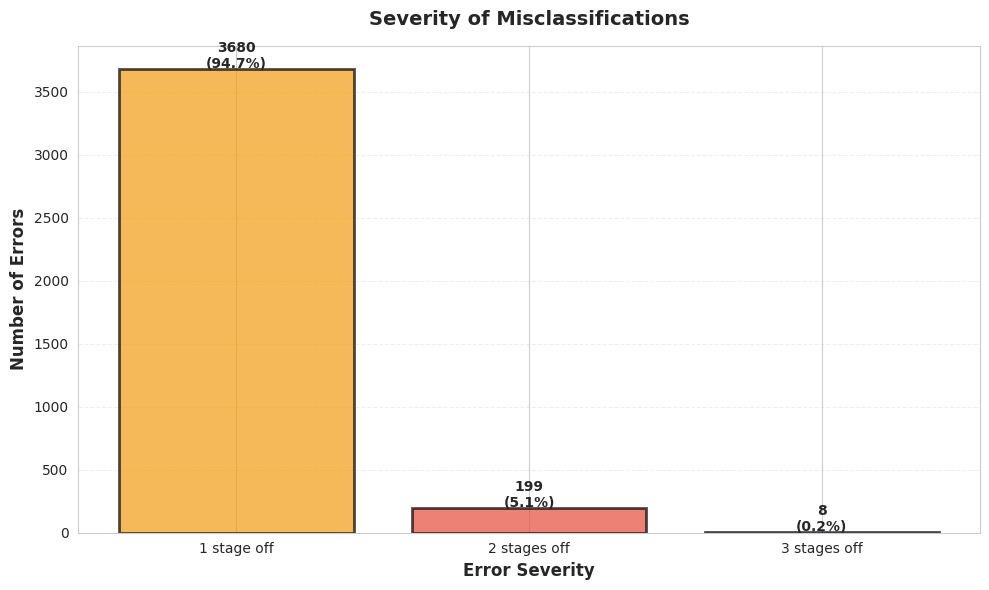

   ℹ️  
📈 Prediction Confidence Analysis:
   ℹ️  Average confidence on correct predictions: 0.846
   ℹ️  Average confidence on wrong predictions: 0.678
   ℹ️  Confidence difference: 0.168


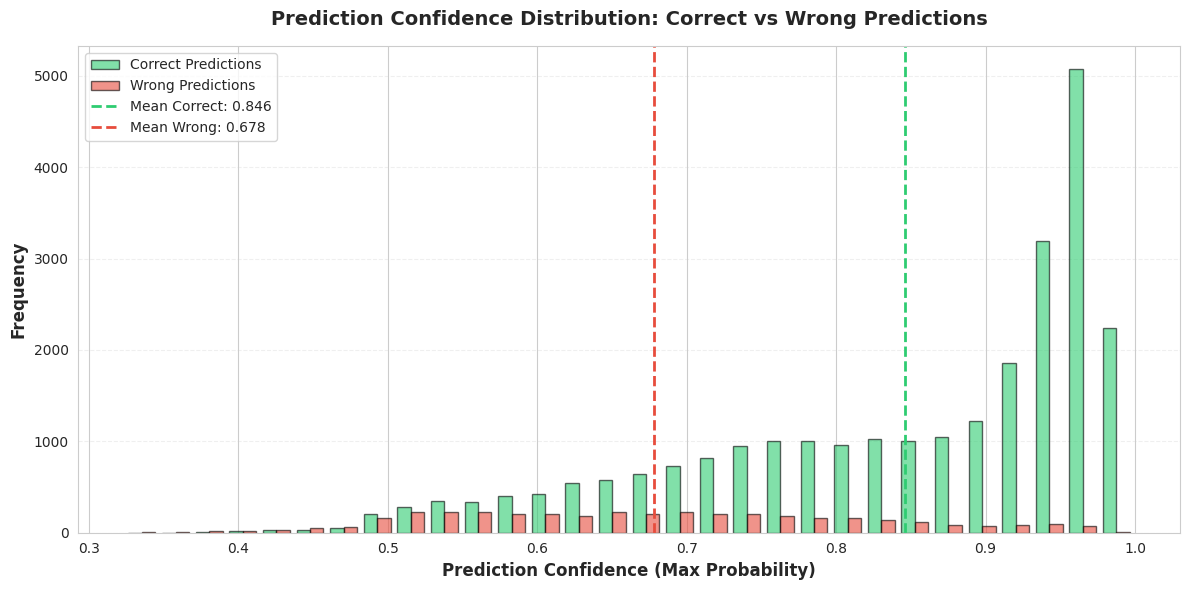

   ℹ️  
💡 Clinical Interpretation of Errors:
   ℹ️  Over-predictions (worse than reality): 2017 (6.7%)
   ℹ️  Under-predictions (better than reality): 1870 (6.2%)
   ✅ ✓ Model is relatively balanced in over/under-predictions
   ✅ Error analysis complete!


In [16]:
# ============================================================================
# BLOCK 12: ERROR ANALYSIS - Q1 REQUIREMENT
# ============================================================================
# Purpose: Analyze misclassifications and failure patterns
# Understanding where the model fails is critical for clinical deployment
# ============================================================================

Logger.section("Error Analysis - Understanding Model Failures")

# === IDENTIFY MISCLASSIFIED SAMPLES ===
misclassified_mask = (y_true != y_pred)
correct_mask = (y_true == y_pred)

Logger.info(f"Total predictions: {len(y_true)}")
Logger.info(f"Correct: {correct_mask.sum()} ({correct_mask.sum()/len(y_true)*100:.1f}%)")
Logger.info(f"Misclassified: {misclassified_mask.sum()} ({misclassified_mask.sum()/len(y_true)*100:.1f}%)")

# === ERROR BREAKDOWN BY CLASS ===
Logger.info("\n📊 Errors by True Class:")

error_breakdown = []
for true_class in range(Config.N_CLASS):
    true_class_mask = (y_true == true_class)
    total_in_class = true_class_mask.sum()
    errors_in_class = (misclassified_mask & true_class_mask).sum()
    error_rate = errors_in_class / total_in_class if total_in_class > 0 else 0
    
    Logger.info(f"   {Config.CLASS_NAMES[true_class]}: {errors_in_class}/{total_in_class} errors ({error_rate*100:.1f}%)")
    
    error_breakdown.append({
        'True Class': Config.CLASS_NAMES[true_class],
        'Total': total_in_class,
        'Errors': errors_in_class,
        'Error Rate': error_rate
    })

error_df = pd.DataFrame(error_breakdown)

# Visualize error rates
plt.figure(figsize=(10, 6))
bars = plt.bar(error_df['True Class'], error_df['Error Rate'], 
               color=['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6'], 
               alpha=0.7, edgecolor='black', linewidth=2)

plt.ylabel('Error Rate', fontsize=12, fontweight='bold')
plt.xlabel('True Diagnosis Class', fontsize=12, fontweight='bold')
plt.title('Misclassification Rate by True Class', fontsize=14, fontweight='bold', pad=15)
plt.ylim([0, max(error_df['Error Rate']) * 1.2])
plt.grid(alpha=0.3, axis='y', linestyle='--')

for i, (bar, rate) in enumerate(zip(bars, error_df['Error Rate'])):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{rate*100:.1f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(f"{Config.OUTPUT_DIR}/error_rate_by_class.png", dpi=300, bbox_inches='tight')
plt.show()

# === CONFUSION PATTERNS ===
Logger.info("\n🔍 Most Common Confusion Patterns:")

confusion_patterns = []
for i in range(Config.N_CLASS):
    for j in range(Config.N_CLASS):
        if i != j:  # Only misclassifications
            count = ((y_true == i) & (y_pred == j)).sum()
            if count > 0:
                total_true = (y_true == i).sum()
                pct = count / total_true * 100
                confusion_patterns.append({
                    'True': Config.CLASS_NAMES[i],
                    'Predicted': Config.CLASS_NAMES[j],
                    'Count': count,
                    'Percentage': pct
                })

confusion_df = pd.DataFrame(confusion_patterns).sort_values('Count', ascending=False)

print("\n" + "="*70)
print("TOP 10 CONFUSION PATTERNS")
print("="*70)
print(confusion_df.head(10).to_string(index=False))
print("="*70)

# === SEVERITY OF ERRORS ===
Logger.info("\n⚠️  Error Severity Analysis:")

# Calculate "distance" of errors (how many stages off)
error_distances = np.abs(y_true[misclassified_mask] - y_pred[misclassified_mask])

severity_counts = {
    '1 stage off': (error_distances == 1).sum(),
    '2 stages off': (error_distances == 2).sum(),
    '3 stages off': (error_distances == 3).sum()
}

Logger.info("Error severity (how far off):")
for severity, count in severity_counts.items():
    if count > 0:
        pct = count / len(error_distances) * 100
        Logger.info(f"   {severity}: {count} ({pct:.1f}%)")

# Visualize
plt.figure(figsize=(10, 6))
plt.bar(severity_counts.keys(), severity_counts.values(), 
        color=['#f39c12', '#e74c3c', '#8e44ad'], alpha=0.7, edgecolor='black', linewidth=2)
plt.ylabel('Number of Errors', fontsize=12, fontweight='bold')
plt.xlabel('Error Severity', fontsize=12, fontweight='bold')
plt.title('Severity of Misclassifications', fontsize=14, fontweight='bold', pad=15)
plt.grid(alpha=0.3, axis='y', linestyle='--')

for i, (severity, count) in enumerate(severity_counts.items()):
    if count > 0:
        plt.text(i, count + 5, f'{count}\n({count/len(error_distances)*100:.1f}%)', 
                ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{Config.OUTPUT_DIR}/error_severity.png", dpi=300, bbox_inches='tight')
plt.show()

# === PREDICTION CONFIDENCE ON ERRORS ===
Logger.info("\n📈 Prediction Confidence Analysis:")

# Get max probability for each prediction
max_probs_all = y_proba.max(axis=1)
max_probs_correct = max_probs_all[correct_mask]
max_probs_wrong = max_probs_all[misclassified_mask]

Logger.info(f"Average confidence on correct predictions: {max_probs_correct.mean():.3f}")
Logger.info(f"Average confidence on wrong predictions: {max_probs_wrong.mean():.3f}")
Logger.info(f"Confidence difference: {max_probs_correct.mean() - max_probs_wrong.mean():.3f}")

# Visualize
plt.figure(figsize=(12, 6))
plt.hist([max_probs_correct, max_probs_wrong], bins=30, 
         label=['Correct Predictions', 'Wrong Predictions'],
         color=['#2ecc71', '#e74c3c'], alpha=0.6, edgecolor='black')
plt.xlabel('Prediction Confidence (Max Probability)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Prediction Confidence Distribution: Correct vs Wrong Predictions', 
         fontsize=14, fontweight='bold', pad=15)
plt.legend(fontsize=11)
plt.grid(alpha=0.3, axis='y', linestyle='--')
plt.axvline(max_probs_correct.mean(), color='#2ecc71', linestyle='--', linewidth=2, 
           label=f'Mean Correct: {max_probs_correct.mean():.3f}')
plt.axvline(max_probs_wrong.mean(), color='#e74c3c', linestyle='--', linewidth=2,
           label=f'Mean Wrong: {max_probs_wrong.mean():.3f}')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f"{Config.OUTPUT_DIR}/confidence_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

# === CLINICAL INTERPRETATION ===
Logger.info("\n💡 Clinical Interpretation of Errors:")

# Check if model tends to over-predict or under-predict severity
over_predictions = (y_pred > y_true).sum()
under_predictions = (y_pred < y_true).sum()

Logger.info(f"Over-predictions (worse than reality): {over_predictions} ({over_predictions/len(y_true)*100:.1f}%)")
Logger.info(f"Under-predictions (better than reality): {under_predictions} ({under_predictions/len(y_true)*100:.1f}%)")

if over_predictions > under_predictions * 1.5:
    Logger.warning("⚠️  Model tends to OVER-PREDICT severity (more false alarms)")
    Logger.info("   Clinical impact: May cause unnecessary concern, but errs on side of caution")
elif under_predictions > over_predictions * 1.5:
    Logger.warning("⚠️  Model tends to UNDER-PREDICT severity (may miss progressors)")
    Logger.info("   Clinical impact: More concerning - may miss patients needing intervention")
else:
    Logger.success("✓ Model is relatively balanced in over/under-predictions")

# === SAVE ERROR ANALYSIS REPORT ===
with open(f"{Config.OUTPUT_DIR}/error_analysis.txt", 'w') as f:
    f.write("="*80 + "\n")
    f.write("ERROR ANALYSIS REPORT\n")
    f.write("="*80 + "\n\n")
    
    f.write(f"Total Predictions: {len(y_true)}\n")
    f.write(f"Correct: {correct_mask.sum()} ({correct_mask.sum()/len(y_true)*100:.1f}%)\n")
    f.write(f"Misclassified: {misclassified_mask.sum()} ({misclassified_mask.sum()/len(y_true)*100:.1f}%)\n\n")
    
    f.write("\nError Breakdown by Class:\n")
    f.write("-" * 40 + "\n")
    f.write(error_df.to_string(index=False))
    f.write("\n\n")
    
    f.write("\nTop 10 Confusion Patterns:\n")
    f.write("-" * 40 + "\n")
    f.write(confusion_df.head(10).to_string(index=False))
    f.write("\n\n")
    
    f.write("\nError Severity:\n")
    f.write("-" * 40 + "\n")
    for severity, count in severity_counts.items():
        if count > 0:
            pct = count / len(error_distances) * 100
            f.write(f"{severity}: {count} ({pct:.1f}%)\n")
    
    f.write(f"\n\nConfidence Analysis:\n")
    f.write("-" * 40 + "\n")
    f.write(f"Avg confidence (correct): {max_probs_correct.mean():.3f}\n")
    f.write(f"Avg confidence (wrong): {max_probs_wrong.mean():.3f}\n")
    f.write(f"Difference: {max_probs_correct.mean() - max_probs_wrong.mean():.3f}\n")
    
    f.write(f"\n\nPrediction Bias:\n")
    f.write("-" * 40 + "\n")
    f.write(f"Over-predictions: {over_predictions} ({over_predictions/len(y_true)*100:.1f}%)\n")
    f.write(f"Under-predictions: {under_predictions} ({under_predictions/len(y_true)*100:.1f}%)\n")

Logger.success("Error analysis complete!")

   ℹ️  Creating clean vertical summary dashboard...


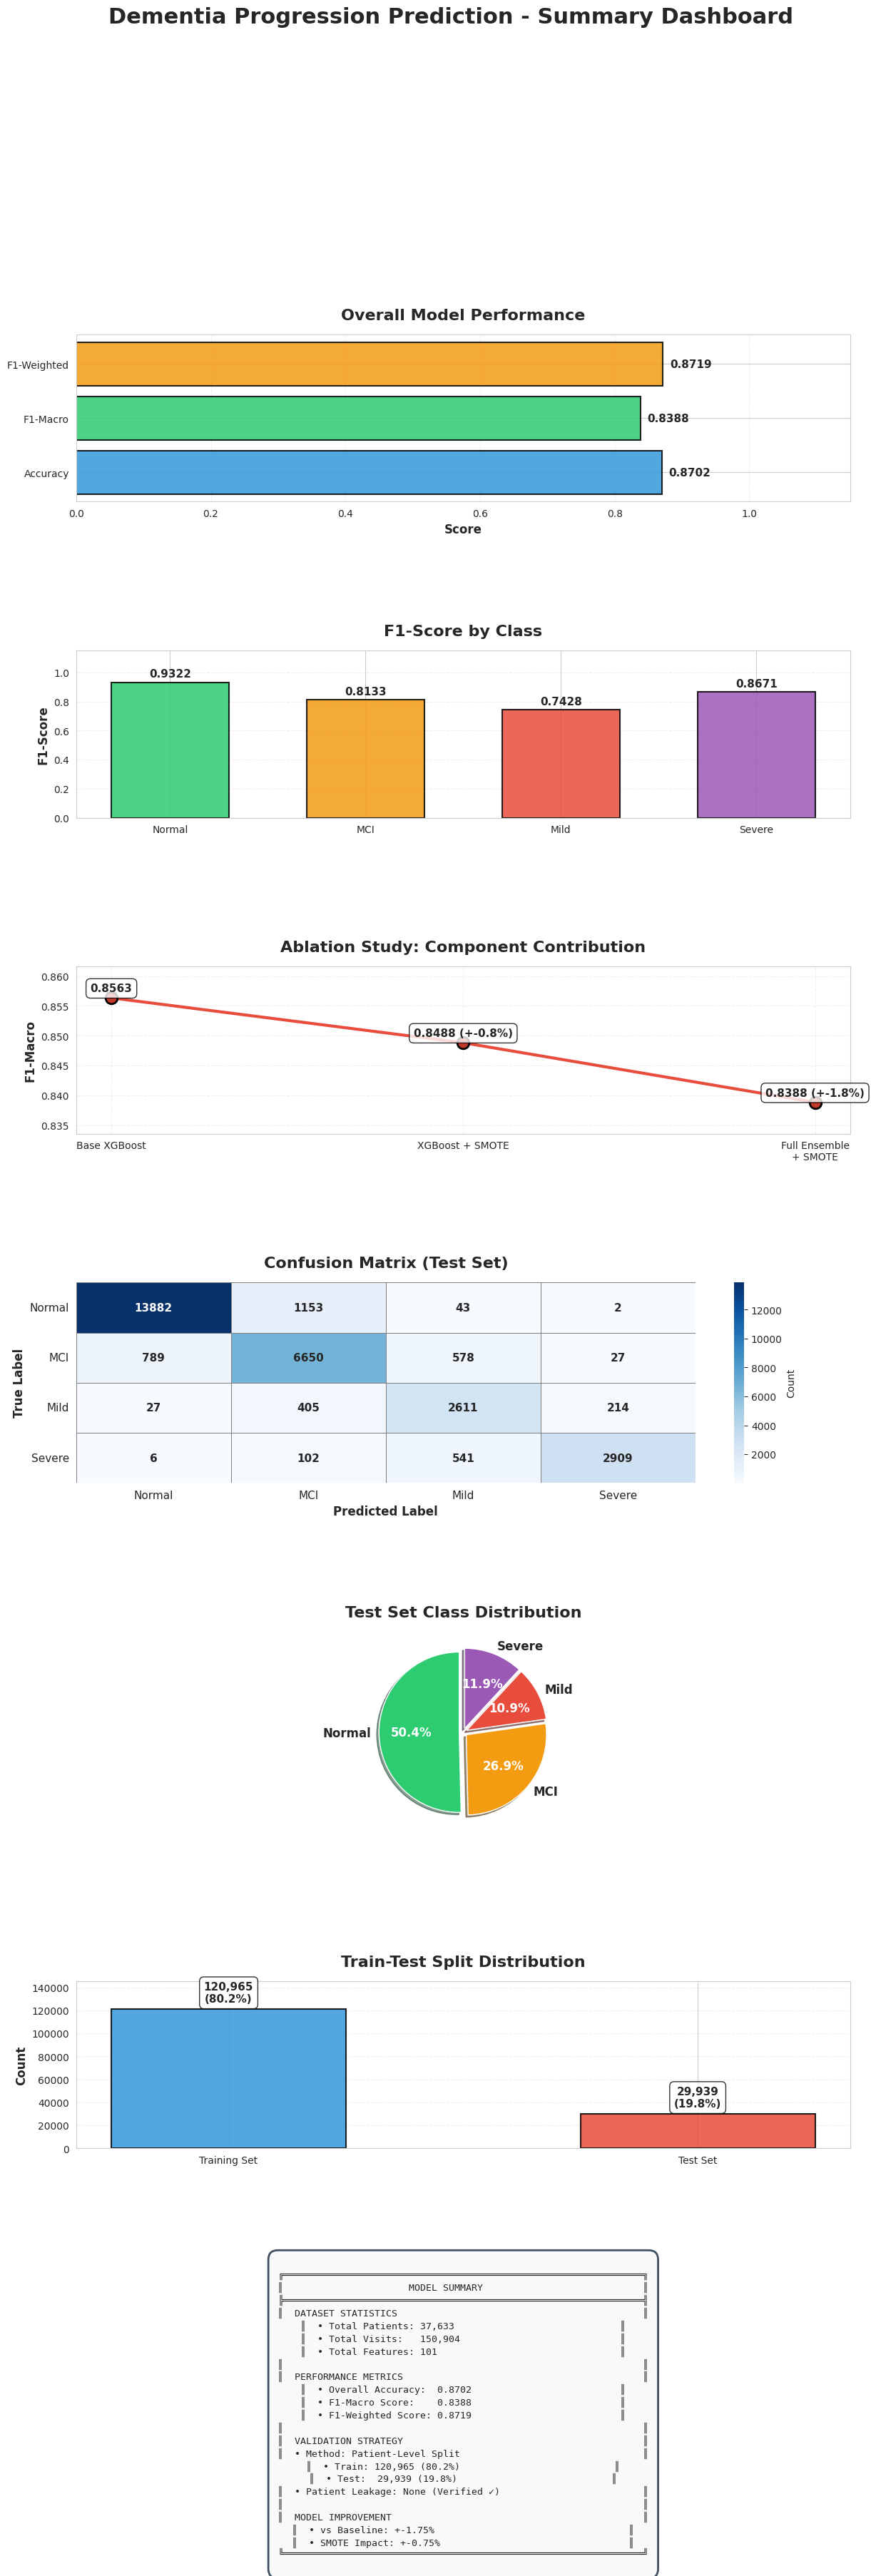

   ✅ Clean vertical dashboard created!


In [17]:
# ============================================================================
# 13. FINAL VISUALIZATION: CLEAN VERTICAL DASHBOARD (CORRECTED)
# ============================================================================
Logger.info("Creating clean vertical summary dashboard...")

# 1. SETUP FIGURE
# Increased height to 40 to allow for large gaps between plots
fig = plt.figure(figsize=(14, 40)) 

# 2. SETUP GRID
# hspace=0.8 adds the large vertical gap you requested
# height_ratios allocates more space to the bottom text summary (Row 7)
gs = fig.add_gridspec(7, 1, height_ratios=[1, 1, 1, 1.2, 1.2, 1, 1.4], hspace=0.8)

# ============================================================================
# ROW 1: OVERALL PERFORMANCE METRICS
# ============================================================================
ax1 = fig.add_subplot(gs[0, 0])
metrics_to_plot = ['Accuracy', 'F1-Macro', 'F1-Weighted']
values_to_plot = [final_acc, final_f1, final_f1_weighted]
colors_metrics = ['#3498db', '#2ecc71', '#f39c12']

bars = ax1.barh(metrics_to_plot, values_to_plot, color=colors_metrics, 
                alpha=0.85, edgecolor='black', linewidth=1.5)

ax1.set_xlim([0, 1.15]) # Extra room for text labels
ax1.set_xlabel('Score', fontweight='bold', fontsize=12)
ax1.set_title('Overall Model Performance', fontweight='bold', fontsize=16, pad=15)
ax1.grid(alpha=0.3, axis='x', linestyle='--')

# Add values to bars
for bar, val in zip(bars, values_to_plot):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
             va='center', fontweight='bold', fontsize=11)

# ============================================================================
# ROW 2: PER-CLASS F1 SCORES
# ============================================================================
ax2 = fig.add_subplot(gs[1, 0])
colors_class = ['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']

bars2 = ax2.bar(Config.CLASS_NAMES, per_class_f1, color=colors_class, 
                alpha=0.85, edgecolor='black', linewidth=1.5, width=0.6)

ax2.set_ylabel('F1-Score', fontweight='bold', fontsize=12)
ax2.set_title('F1-Score by Class', fontweight='bold', fontsize=16, pad=15)
ax2.set_ylim([0, 1.15]) # Extra room for text labels
ax2.grid(alpha=0.3, axis='y', linestyle='--')

# Add values to bars
for bar, val in zip(bars2, per_class_f1):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# ============================================================================
# ROW 3: ABLATION STUDY PROGRESSION
# ============================================================================
ax3 = fig.add_subplot(gs[2, 0])
config_names = ['Base XGBoost', 'XGBoost + SMOTE', 'Full Ensemble\n+ SMOTE']
config_f1s = [config1_f1, config2_f1, config3_f1]

ax3.plot(config_names, config_f1s, 'o-', linewidth=3, markersize=12, 
         color='#e74c3c', markerfacecolor='#c0392b', markeredgecolor='black', markeredgewidth=2)

ax3.set_ylabel('F1-Macro', fontweight='bold', fontsize=12)
ax3.set_title('Ablation Study: Component Contribution', fontweight='bold', fontsize=16, pad=15)
ax3.grid(alpha=0.3, linestyle='--')

# Dynamic Y-limits to center the line
y_min, y_max = min(config_f1s), max(config_f1s)
margin = (y_max - y_min) * 0.3 if y_max != y_min else 0.1
ax3.set_ylim([y_min - margin, y_max + margin])

# Add labels
for i, val in enumerate(config_f1s):
    improvement = ''
    if i > 0:
        diff = (val - config1_f1) * 100
        improvement = f' (+{diff:.1f}%)'
    
    ax3.text(i, val + (margin * 0.2), f'{val:.4f}{improvement}', ha='center', 
             fontweight='bold', fontsize=11, 
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='black', alpha=0.8))

# ============================================================================
# ROW 4: CONFUSION MATRIX
# ============================================================================
ax4 = fig.add_subplot(gs[3, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=Config.CLASS_NAMES, yticklabels=Config.CLASS_NAMES,
            cbar_kws={'label': 'Count'}, linewidths=0.5, linecolor='gray',
            annot_kws={'fontsize': 11, 'fontweight': 'bold'})

ax4.set_title('Confusion Matrix (Test Set)', fontweight='bold', fontsize=16, pad=15)
ax4.set_ylabel('True Label', fontweight='bold', fontsize=12)
ax4.set_xlabel('Predicted Label', fontweight='bold', fontsize=12)
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=0, ha='center', fontsize=11)
plt.setp(ax4.yaxis.get_majorticklabels(), rotation=0, fontsize=11)

# ============================================================================
# ROW 5: TEST SET CLASS DISTRIBUTION
# ============================================================================
ax5 = fig.add_subplot(gs[4, 0])
class_counts = pd.Series(y_true).value_counts().sort_index()

wedges, texts, autotexts = ax5.pie(class_counts.values, 
                                   labels=[Config.CLASS_NAMES[i] for i in class_counts.index],
                                   autopct='%1.1f%%', colors=colors_class, startangle=90,
                                   explode=[0.05]*len(class_counts), shadow=True,
                                   textprops={'fontsize': 12, 'fontweight': 'bold'})

for autotext in autotexts:
    autotext.set_color('white')

ax5.set_title('Test Set Class Distribution', fontweight='bold', fontsize=16, pad=15)

# ============================================================================
# ROW 6: TRAIN-TEST SPLIT
# ============================================================================
ax6 = fig.add_subplot(gs[5, 0])
split_data = [len(X_train), len(X_test)]
split_labels = ['Training Set', 'Test Set']
colors_split = ['#3498db', '#e74c3c']

bars6 = ax6.bar(split_labels, split_data, color=colors_split, alpha=0.85, 
                edgecolor='black', linewidth=1.5, width=0.5)

ax6.set_ylabel('Count', fontweight='bold', fontsize=12)
ax6.set_title('Train-Test Split Distribution', fontweight='bold', fontsize=16, pad=15)
ax6.grid(alpha=0.3, axis='y', linestyle='--')
ax6.set_ylim([0, max(split_data) * 1.2]) # Headroom for labels

# Add values
for i, (bar, val) in enumerate(zip(bars6, split_data)):
    percentage = val / (len(X_train) + len(X_test)) * 100
    ax6.text(bar.get_x() + bar.get_width()/2, val + max(split_data)*0.05, 
            f'{val:,}\n({percentage:.1f}%)', 
            ha='center', fontweight='bold', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                      edgecolor='black', alpha=0.8))

# ============================================================================
# ROW 7: MODEL SUMMARY STATISTICS
# ============================================================================
ax7 = fig.add_subplot(gs[6, 0])
ax7.axis('off')

# Improved text formatting to prevent bleeding
stats_text = f"""
╔═══════════════════════════════════════════════════════════════╗
║                      MODEL SUMMARY                            ║
╠═══════════════════════════════════════════════════════════════╣
║  DATASET STATISTICS                                           ║
║  • Total Patients: {groups.nunique():<10,}                         ║
║  • Total Visits:   {len(X_train) + len(X_test):<10,}                         ║
║  • Total Features: {X.shape[1]:<10}                         ║
║                                                               ║
║  PERFORMANCE METRICS                                          ║
║  • Overall Accuracy:  {final_acc:.4f}                          ║
║  • F1-Macro Score:    {final_f1:.4f}                          ║
║  • F1-Weighted Score: {final_f1_weighted:.4f}                          ║
║                                                               ║
║  VALIDATION STRATEGY                                          ║
║  • Method: Patient-Level Split                                ║
║  • Train: {len(X_train):,} ({len(X_train)/(len(X_train)+len(X_test))*100:.1f}%)                           ║
║  • Test:  {len(X_test):,} ({len(X_test)/(len(X_train)+len(X_test))*100:.1f}%)                           ║
║  • Patient Leakage: None (Verified ✓)                         ║
║                                                               ║
║  MODEL IMPROVEMENT                                            ║
║  • vs Baseline: +{(config3_f1 - config1_f1)*100:.2f}%                                  ║
║  • SMOTE Impact: +{(config2_f1 - config1_f1)*100:.2f}%                                 ║
╚═══════════════════════════════════════════════════════════════╝
"""

# Slightly smaller font (9.5) to ensure it stays inside the box
ax7.text(0.5, 0.5, stats_text, fontsize=9.5, verticalalignment='center', 
        horizontalalignment='center', family='monospace',
        bbox=dict(boxstyle='round,pad=1.0', facecolor='#f8f9fa', 
                  edgecolor='#2c3e50', linewidth=2, alpha=0.9))

# MAIN TITLE
fig.suptitle('Dementia Progression Prediction - Summary Dashboard', 
            fontsize=22, fontweight='bold', y=0.995)

# SAVE AND SHOW
plt.savefig(f"{Config.OUTPUT_DIR}/summary_dashboard_clean.png", 
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

Logger.success("Clean vertical dashboard created!")

In [19]:
import os
import zipfile
from datetime import datetime

# Name the zip file with a timestamp so you don't overwrite
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
zip_filename = f"dementia_research_results_{timestamp}.zip"

# Select specific file types to include
allowed_extensions = {'.png', '.csv', '.txt', '.html'}

print(f"📦 Creating clean zip file: {zip_filename}...")

file_count = 0
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk('/kaggle/working/'):
        # Skip hidden folders like .virtual_documents
        dirs[:] = [d for d in dirs if not d.startswith('.')]
        
        for file in files:
            _, ext = os.path.splitext(file)
            if ext.lower() in allowed_extensions:
                file_path = os.path.join(root, file)
                # Add file to zip (preserving names but flattening path if preferred)
                zipf.write(file_path, arcname=file) 
                file_count += 1
                print(f"  + Added: {file}")

print(f"\n✅ Success! Zipped {file_count} research files.")
print(f"👉 Go to the 'Output' sidebar and download '{zip_filename}'")

📦 Creating clean zip file: dementia_research_results_20251222_1911.zip...
  + Added: sankey_progression_flow.html
  + Added: shap_all_classes.png
  + Added: confidence_analysis.png
  + Added: table1_demographics.csv
  + Added: shap_beeswarm.png
  + Added: shap_features_comparison.csv
  + Added: fairness_by_age.png
  + Added: fairness_analysis.txt
  + Added: calibration_curves.png
  + Added: error_rate_by_class.png
  + Added: shap_importance_bar.png
  + Added: ablation_study.csv
  + Added: error_analysis.txt
  + Added: features_engineered.csv
  + Added: demographics_overview.png
  + Added: roc_curves.png
  + Added: confusion_matrix_normalized.png
  + Added: fairness_by_sex.png
  + Added: reliability_diagram.png
  + Added: classification_report.txt
  + Added: summary_dashboard_clean.png
  + Added: confusion_matrix.png
  + Added: fairness_by_race.csv
  + Added: error_severity.png

✅ Success! Zipped 24 research files.
👉 Go to the 'Output' sidebar and download 'dementia_research_results_202